In [1]:
import csv
import os
import torch
import numpy as np
from typing import Optional, Dict, Any
from dataclasses import dataclass


@dataclass
class LogEntry:
    """Data structure for a single log entry"""

    step: int
    param_id: int
    grad_norm: float
    grad_std: float
    beta: float
    lr: float
    error_norm: float
    error_norm_sqrt: float
    error_svd: float
    rank_U: int
    rank_V: int
    max_U: float
    min_U: float
    max_V: float
    min_V: float
    U_shape: tuple
    V_shape: tuple


class AdaGramLogger:
    """Dedicated logger for AdaGram optimizer statistics"""

    def __init__(
        self,
        log_file: str,
        task: str = "LinReg",
        lr: float = 1.0,
        max_rank: Optional[int] = None,
        enable_state_saving: bool = True,
    ):
        """
        Initialize the logger

        Args:
            log_file: Base path for log file
            task: Task name for identification
            lr: Learning rate for file naming
            max_rank: Maximum rank for file naming
            full_svd: Whether using full SVD
            enable_state_saving: Whether to save state matrices
        """
        self.task = task
        self.lr = lr
        self.max_rank = max_rank
        # self.full_svd = full_svd
        self.enable_state_saving = enable_state_saving

        # Generate log file path
        if log_file:
            self.log_file = log_file
        else:
            self.log_file = "results/loggs/adagram_logs.csv"

        self._initialize_csv()

        # Create state directory if needed
        if enable_state_saving:
            os.makedirs("state_G_binclass", exist_ok=True)

    def _initialize_csv(self):
        """Initialize CSV file with headers if it doesn't exist"""
        os.makedirs(os.path.dirname(self.log_file), exist_ok=True)

        if not os.path.isfile(self.log_file):
            with open(self.log_file, "w", newline="") as f:
                writer = csv.writer(f)
                writer.writerow(
                    [
                        "step",
                        "param_id",
                        "grad_norm",
                        "grad_std",
                        "beta",
                        "lr",
                        "error_norm",
                        "error_norm_sqrt",
                        "error_svd",
                        "rank_U",
                        "rank_V",
                        "max_U",
                        "min_U",
                        "max_V",
                        "min_V",
                        "U_shape_0",
                        "U_shape_1",
                        "V_shape_0",
                        "V_shape_1",
                    ]
                )

    def log_step(self, entry: LogEntry):
        """Log a single optimization step"""
        with open(self.log_file, "a", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(
                [
                    entry.step,
                    entry.param_id,
                    entry.grad_norm,
                    entry.grad_std,
                    entry.beta,
                    entry.lr,
                    entry.error_norm,
                    entry.error_norm_sqrt,
                    entry.error_svd,
                    entry.rank_U,
                    entry.rank_V,
                    entry.max_U,
                    entry.min_U,
                    entry.max_V,
                    entry.min_V,
                    entry.U_shape[0],
                    entry.U_shape[1],
                    entry.V_shape[0],
                    entry.V_shape[1],
                ]
            )

    def save_state_matrix(self, G_matrix: torch.Tensor, epoch: int):
        """Save state matrix G to compressed numpy file"""
        if not self.enable_state_saving:
            return

        G_np = G_matrix.cpu().numpy()
        filename = f"state_G_binclass/{self.task}_state_G_lr_{self.lr}_rank_{self.max_rank}_epoch_{epoch}.npz"
        np.savez_compressed(filename, G=G_np)

    def log_optimizer_step(
        self,
        step_count: int,
        param_id: int,
        grad_vector: torch.Tensor,
        beta: torch.Tensor,
        lr: float,
        error_norm: torch.Tensor,
        error_norm_sqrt: torch.Tensor,
        reconstruct_error: torch.Tensor,
        state: Dict[str, Any],
        epoch: Optional[int] = None,
    ):
        """
        Convenience method to log all optimizer statistics

        Args:
            step_count: Current step number
            param_id: Parameter index
            grad_vector: Gradient vector
            beta: Beta value
            lr: Learning rate
            error_norm: Reconstruction error norm
            reconstruct_error: SVD reconstruction error
            state: Optimizer state dictionary
            epoch: Current epoch (for state saving)
        """
        # Extract statistics
        grad_norm = torch.sqrt(torch.dot(grad_vector, grad_vector))
        grad_std = torch.std(grad_vector)

        # Extract matrix statistics
        if "P" in state and "Q" in state:
            rank_U = torch.linalg.matrix_rank(state["P"])
            rank_V = torch.linalg.matrix_rank(state["Q"])
            max_U = state["P"].max()
            max_V = state["Q"].max()
            min_U = state["P"].min()
            min_V = state["Q"].min()
            U_shape = state["P"].shape
            V_shape = state["Q"].shape
        else:
            rank_U = rank_V = max_U = max_V = min_U = min_V = torch.tensor(0)
            U_shape = V_shape = (0, 0)

        # Create log entry
        entry = LogEntry(
            step=step_count,
            param_id=param_id,
            grad_norm=grad_norm.item(),
            grad_std=grad_std.item(),
            beta=beta.item(),
            lr=lr,
            error_norm=error_norm.item(),
            error_norm_sqrt=error_norm_sqrt.item(),
            error_svd=reconstruct_error.item(),
            rank_U=rank_U.item(),
            rank_V=rank_V.item(),
            max_U=max_U.item(),
            min_U=min_U.item(),
            max_V=max_V.item(),
            min_V=min_V.item(),
            U_shape=U_shape,
            V_shape=V_shape,
        )

        # Log the entry
        self.log_step(entry)

        # Save state matrix if requested
        if epoch is not None and "G" in state:
            self.save_state_matrix(state["G"], epoch)

In [2]:
import torch
from torch.optim import Optimizer
import numpy as np
import os

from typing import Optional, Dict, Any, Tuple
from abc import ABC

# import libcontext
#from utils.Logger import AdaGramLogger

#from line_profiler import profile


class AdaGram(Optimizer, ABC):
    """
    Abstract base class for AdaGram optimizers with pluggable update strategies (different Q, P updates).

    At the end of the step, it replaces p.grad with the preconditioned gradient
    for analysis purposes.
    """

    def __init__(
        self,
        params,
        lr: float = 1.0,
        eps: float = 1e-10,
        weight_decay: float = 0,
        max_rank: Optional[int] = None,
        log_file: str = "results/adagram_logs.csv",
        task: str = "LinReg",
        save_dir: str = "matrix_G",
        logger: Optional[AdaGramLogger] = None,
        enable_logging: bool = False,
        save_matrix: bool = False,
    ):

        if lr <= 0.0:
            raise ValueError(f"Invalid learning rate: {lr}")
        if eps <= 0.0:
            raise ValueError(f"Invalid epsilon value: {eps}")
        if weight_decay < 0.0:
            raise ValueError(f"Invalid weight_decay value: {weight_decay}")

        defaults = dict(lr=lr, eps=eps, weight_decay=weight_decay, max_rank=max_rank)
        super(AdaGram, self).__init__(params, defaults)
        self.lr = lr
        self.eps = eps
        self.max_rank = max_rank
        self.task = task
        self.enable_logging = enable_logging
        self.save_matrix = save_matrix

        # Initialize logger
        if enable_logging:
            if logger is None:
                self.logger = AdaGramLogger(
                    log_file=log_file,
                    task=task,
                    lr=lr,
                    max_rank=max_rank,
                )
            else:
                self.logger = logger
        else:
            self.logger = None

    def _compute_alpha(
        self, g_bar_norm_sq: torch.Tensor, eps: float = 1e-10
    ) -> torch.Tensor:
        """Compute alpha_t that satisfies the equation (6) in the theorem."""
        return ((1 + g_bar_norm_sq).sqrt() - 1) / g_bar_norm_sq

    def _compute_beta(
        self, alpha: torch.Tensor, g_bar_norm_sq: torch.Tensor
    ) -> torch.Tensor:
        """Compute beta_t as defined in the theorem."""
        return alpha / (1 + alpha * g_bar_norm_sq)
    
    def _faster_svd(self, state):
        ## faster svd variant with the QR  
        Qp, Rp = torch.linalg.qr(state["P"], mode='reduced')
        Qq, Rq = torch.linalg.qr(state["Q"], mode='reduced')
        small_matrix = Rp @ Rq.T
        U_s, S, Vh_s = torch.linalg.svd(small_matrix, full_matrices=False)

        if self.max_rank is not None:
            U_s = U_s[:, :self.max_rank]
            S = S[:self.max_rank]
            Vh_s = Vh_s[:self.max_rank, :]

        U = Qp @ U_s        # [n, k]
        V = Qq @ Vh_s.T     # [n, k]
        state["U"], state["S"], state["V"] = U, S, V

        state["S"] = torch.diag(state["S"])
        state["U"] = state["U"]
        state["V"] = state["V"]

    def initialize(self, state: Dict[str, Any], n: int, grad: torch.Tensor):
        """Initialize optimizer state"""
        max_rank = self.max_rank
        if not max_rank:
            max_rank = n
        
        state["L_0"] = (np.sqrt(self.eps))

        if self.enable_logging:                  
            state["G"] = self.eps * torch.eye(n, device=grad.device, dtype=grad.dtype)
            state["L_t"] = state["L_0"] * torch.eye(n, device=grad.device, dtype=grad.dtype)

            result = state["L_t"] @ state["L_t"].T
            target = state["G"]
            error_norm = torch.norm(torch.abs(target - result)) / torch.norm(target)
            print('initial norm', error_norm)

        
        state["L_0_inv"] = 1 / state["L_0"]
        state["step_count"] = 0

    def update_grad_vector(self, state, grad_vector):
        d = state["L_0_inv"]  # 1D tensor, diagonal entries
        u = grad_vector * d   # elementwise

        if "P" in state:
            P, Q = state["P"], state["Q"]
            if len(u.shape) == 1:
                u = u.view(-1, 1)
            x = Q.T @ u   # shape: (q_dim,)
            if len(x.shape) > 0:
                Px = P @ x    # shape: (n_dim,)
            else: 
                Px = P * x
            new_g_bar = (u - Px).reshape(-1)
            return new_g_bar
        else:
            new_g_bar = u.reshape(-1)
            return new_g_bar

    def update_grad_vector_sym(self, state, grad_vector):
        d = state["L_0_inv"]  # 1D tensor, diagonal entries
        u = grad_vector * d   # elementwise

        if "P" in state:
            P, Q = state["P"], state["Q"]
            if len(u.shape) == 1:
                u = u.view(-1, 1)
            x = Q.T @ u   # shape: (q_dim,)
            if len(x.shape) > 0:
                Px = P @ x    # shape: (n_dim,)
            else: 
                Px = P * x
            new_g_bar = (u - Px).reshape(-1)
        else:
            new_g_bar = u.reshape(-1)

        
        if "P" in state:
            P, Q = state["P"], state["Q"]
            if len(new_g_bar.shape) == 1:
                new_g_bar = new_g_bar.view(1, -1)
            # print(Q.shape)
            # print(new_g_bar.shape)
            x_sym = new_g_bar @ Q

            if len(x_sym.shape) > 0:
                x_sym_P = x_sym @ P.T    # shape: (n_dim,)
            else: 
                x_sym_P = x_sym * P
            new_sym_g_bar = d * (new_g_bar - x_sym_P).reshape(-1)
        else:
            new_sym_g_bar = d * new_g_bar
        return new_sym_g_bar


    def calculate_coeffs(
        self, g_bar: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Calculate alpha, beta coefficients"""
        g_bar_norm_sq = torch.dot(g_bar, g_bar)
        alpha = self._compute_alpha(g_bar_norm_sq)
        beta = self._compute_beta(alpha, g_bar_norm_sq)
        return g_bar_norm_sq, alpha, beta

    # @abstractmethod
    def update_PQ(
        self,
        state: Dict[str, Any],
        beta: torch.Tensor,
        g_bar: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Abstract method to update P and Q matrices

        Args:
            state: Optimizer state dictionary
            beta: Beta coefficient
            g_bar: Preconditioned gradient
            grad_vector: Original gradient vector
            alpha: Alpha coefficient

        Returns:
            Tuple of (P, Q, reconstruction_error)
        """
        pass


    def step(self, epoch: Optional[int] = None, closure=None):
        """Performs a single optimization step"""
        loss = None
        if closure is not None:
            loss = closure()

        with torch.no_grad():
            for group in self.param_groups:
                for param_idx, p in enumerate(group["params"]):
                    if p.grad is None:
                        continue
                    
                    grad = p.grad.data
                    state = self.state[p]
                    original_shape = p.data.shape
    
                    grad_vector = grad.reshape(-1)
                    param_vector = p.data.reshape(-1)
                    n = len(grad_vector)
                    
                    # Initialize state if needed
    
                    if len(state) == 0:
                        self.initialize(state, n, grad)
                        if self.enable_logging and self.save_matrix:
                            if (
                                param_idx == 0
                            ):  # Save only for first parameter to avoid too many files
                                filename = f"G_matrix_epoch_0_adagram_task_{getattr(self, 'task_name', 'unknown')}.pt"
                                torch.save(
                                    state["G"], os.path.join(self.save_dir, filename)
                                )
    
                    # Update gradient vector
                    g_bar = self.update_grad_vector(state, grad_vector)

                    ##### HERE SYM VERSION!!!
                        
                    # g_bar_sym = self.update_grad_vector_sym(state, grad_vector)
    
                    g_bar_norm_sq, alpha, beta = self.calculate_coeffs(g_bar)
    
                    # Update P and Q matrices (implemented by subclasses)
                    state["P"], state["Q"], reconstruct_error = self.update_PQ(
                        state,
                        beta,
                        g_bar,
                    )
    
                    if self.enable_logging:
                        identity = torch.eye(n, device=grad.device, dtype=grad.dtype)

                        state["L_t"] = state["L_t"] @ (
                            identity + alpha * torch.ger(g_bar, g_bar)
                        )

                        state["G"] += torch.ger(grad_vector, grad_vector)
                        
                        if self.save_matrix:
                            if (
                                epoch is not None and param_idx == 0
                            ):  
                                filename = f"G_matrix_epoch_{epoch+1}_batch_{state['step_count']}_adagram_task_{getattr(self, 'task_name', 'unknown')}.pt"
                                torch.save(state["G"], os.path.join(self.save_dir, filename))
    
                        eigenvals, eigenvecs = torch.linalg.eigh(state["G"])
                        sqrt_eigenvals = torch.sqrt(eigenvals)
    
                        sqr_G = eigenvecs @ torch.diag(sqrt_eigenvals) @ eigenvecs.T
    
                        v = torch.randn(n, device=grad.device, dtype=grad.dtype)
                        v = v / torch.norm(v)
    
                        y_1 = sqr_G @ v
                        y_2 = state["L_t"] @ v
    
                        error_norm_sqr = torch.norm(y_1 - y_2) / torch.norm(y_1)
    
                        result = state["L_t"] @ state["L_t"].T
                        target = state["G"]
                        error_norm = torch.norm(torch.abs(target - result)) / torch.norm(target)

                    state["step_count"] += 1
    
                    # Log statistics
                    if self.enable_logging and self.logger:
                        self.logger.log_optimizer_step(
                            step_count=state["step_count"],
                            param_id=param_idx,
                            grad_vector=grad_vector,
                            beta=beta,
                            lr=group["lr"],
                            error_norm=error_norm,
                            error_norm_sqrt=error_norm_sqr,
                            reconstruct_error=reconstruct_error,
                            state=state,
                            epoch=epoch,
                        )
    
    
                    # precond_grad = g_bar / torch.sqrt(1 + g_bar_norm_sq)
                    precond_grad = g_bar / torch.sqrt(1 + g_bar_norm_sq)
                    param_vector.add_(precond_grad, alpha=-group["lr"])
                    p.grad.data = precond_grad
                    p.data = param_vector.reshape(original_shape)

        return loss   
        
class AdaGramFR(AdaGram):
    """AdaGramFR - AdaGram with Full Rank reduction using SVD"""

    def __init__(
        self,
        params,
        lr: float = 1.0,
        eps: float = 1e-10,
        weight_decay: float = 0,
        max_rank: Optional[int] = None,
        task: str = "LinReg",
        logger: Optional["AdaGramLogger"] = None,
        enable_logging: bool = False,
        save_matrix: bool = False,
    ):

        super().__init__(
            params=params,
            lr=lr,
            eps=eps,
            weight_decay=weight_decay,
            max_rank=max_rank,
            task=task,
            logger=logger,
            enable_logging=enable_logging,
            save_matrix=save_matrix,
        )


    def reduce_rank_svd(
        self, M: torch.Tensor,  max_rank=None
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        
        U, S, Vh = torch.linalg.svd(M, full_matrices = False)

        if max_rank:
            U_k = U[:, :max_rank]
            S_k = S[:max_rank]
            V_k = Vh[:max_rank, :]

            return U_k, S_k, V_k.T
        else:
            return U, S, Vh.T
    

    # def update_PQ(
    #     self,
    #     state: Dict[str, Any],
    #     beta: torch.Tensor,
    #     g_bar: torch.Tensor,
    # ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:

    #     beta_g = (beta * g_bar).reshape(-1, 1)
    #     g_bar_col = g_bar.reshape(-1, 1)

    #     if "P" not in state:
    #         P = beta_g
    #         Q = g_bar_col
    #         reconstruct_error = torch.tensor(0.0)

    #     else:
    #         v_upd = (g_bar_col - state["Q"] @ (state["P"].T @ g_bar_col)) # update without matrices 

    #         P = torch.concat([state["P"], beta_g], dim=1)
    #         Q = torch.concat([state["Q"], v_upd], dim=1)

    #         reconstruct_error = torch.tensor(0.0)

    #         if self.max_rank is not None and state["P"].shape[1] > self.max_rank:
    #                 self._faster_svd(state)

    #                 if self.enable_logging:
    #                     state["rec_target"] = state["P"] @ state["Q"].T

    #                     reconstruct_error = torch.norm(
    #                         torch.abs(
    #                             state["rec_target"] - (state["U"] @ state["S"] @ state["V"].T)
    #                         )
    #                     ) / torch.norm(state["rec_target"])


    #                 P = state["U"] @ state["S"]
    #                 Q = state["V"]



    #     return P, Q, reconstruct_error
    def update_PQ(
        self,
        state: Dict[str, Any],
        beta: torch.Tensor,
        g_bar: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    
        beta_g = (beta * g_bar).reshape(-1, 1)
        g_bar_col = g_bar.reshape(-1, 1)

        reconstruct_error = torch.tensor(0.0)
    
        if "P" not in state:
            P = beta_g
            Q = g_bar_col
    
        else:
            # Проверяем, не превысили ли мы максимальный ранг
            current_rank = state["P"].shape[1]
            max_allowed = self.max_rank if self.max_rank is not None else current_rank + 1
            
            if current_rank >= max_allowed:
                # Если уже достигли максимального ранга, делаем SVD и обрезаем
                self._faster_svd(state)
                if self.enable_logging:
                    state["rec_target"] = state["P"] @ state["Q"].T
                    reconstruct_error = torch.norm(
                        torch.abs(
                            state["rec_target"] - (state["U"] @ state["S"] @ state["V"].T)
                        )
                    ) / torch.norm(state["rec_target"])
                P = state["U"] @ state["S"]
                Q = state["V"]
            else:
                # Иначе продолжаем накапливать
                v_upd = (g_bar_col - state["Q"] @ (state["P"].T @ g_bar_col))
                P = torch.concat([state["P"], beta_g], dim=1)
                Q = torch.concat([state["Q"], v_upd], dim=1)
                reconstruct_error = torch.tensor(0.0)
    
        return P, Q, reconstruct_error

# MAIN

Using device: cuda
Loading model...


tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

Initializing AdaGramFR optimizer for first 5 blocks...
Processing batches to accumulate Fisher information...


Processing batches: 100%|██████████| 50/50 [01:03<00:00,  1.27s/it]


Extracting P and Q matrices from AdaGramFR...
Full P shape: torch.Size([151154688, 2]), Full Q shape: torch.Size([151154688, 2])
Current rank: 2
Splitting P and Q into blocks (first 5 blocks)...
Block 1: size=12596224, P_block shape=torch.Size([12596224, 2]), Q_block shape=torch.Size([12596224, 2])
Block 2: size=12596224, P_block shape=torch.Size([12596224, 2]), Q_block shape=torch.Size([12596224, 2])
Block 3: size=12596224, P_block shape=torch.Size([12596224, 2]), Q_block shape=torch.Size([12596224, 2])
Block 4: size=12596224, P_block shape=torch.Size([12596224, 2]), Q_block shape=torch.Size([12596224, 2])
Block 5: size=12596224, P_block shape=torch.Size([12596224, 2]), Q_block shape=torch.Size([12596224, 2])
Block 6: size=12596224, P_block shape=torch.Size([12596224, 2]), Q_block shape=torch.Size([12596224, 2])
Block 7: size=12596224, P_block shape=torch.Size([12596224, 2]), Q_block shape=torch.Size([12596224, 2])
Block 8: size=12596224, P_block shape=torch.Size([12596224, 2]), Q_blo

Computing norms: 100%|██████████| 12/12 [00:01<00:00, 10.44it/s]


Generating heatmap visualization for first 5 blocks...


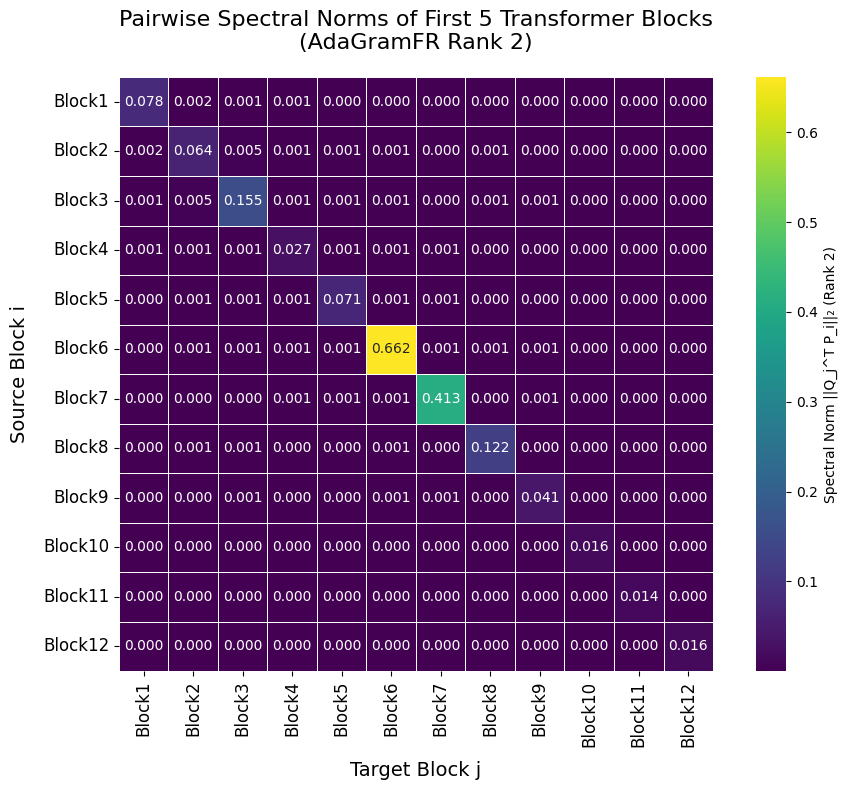

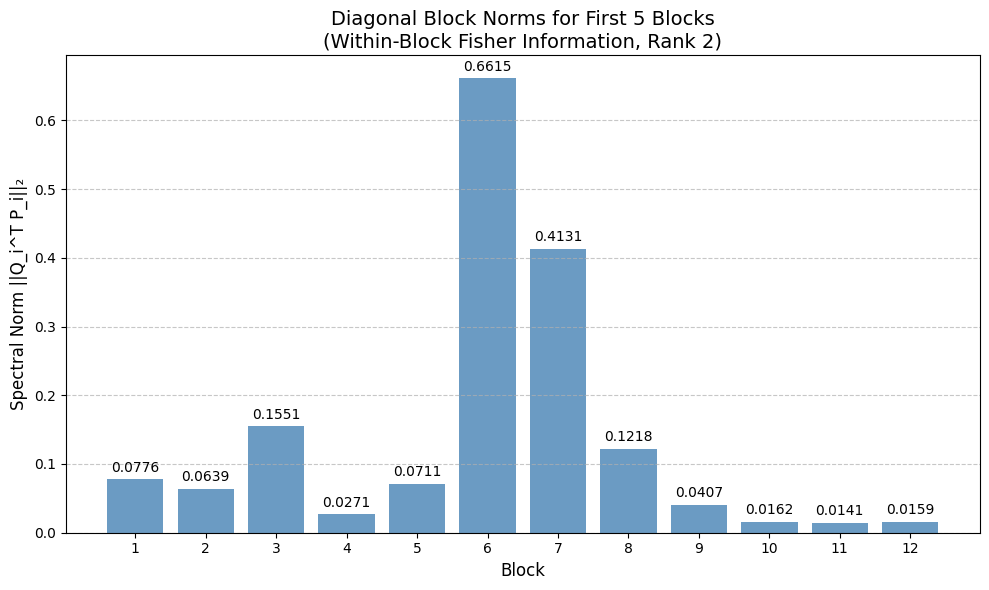


BLOCK NORM STATISTICS FOR FIRST 5 BLOCKS (Rank 2)
Total blocks: 12
Max norm: 0.6615
Min norm: 0.0000
Mean norm: 0.0121
Diagonal mean norm: 0.1398
Off-diagonal mean norm: 0.0005
--------------------------------------------------
Diagonal norms per block:
Block  1: 7.757033e-02
Block  2: 6.390826e-02
Block  3: 1.550534e-01
Block  4: 2.710076e-02
Block  5: 7.113090e-02
Block  6: 6.615344e-01
Block  7: 4.130860e-01
Block  8: 1.218110e-01
Block  9: 4.073875e-02
Block 10: 1.622648e-02
Block 11: 1.409597e-02
Block 12: 1.592610e-02

BLOCK INTERACTION ANALYSIS (First 5 Blocks)
Strongest inter-block interaction: Block 2 → Block 3 with norm 0.0049
Weakest inter-block interaction: Block 12 → Block 1 with norm 0.0000

Average outgoing interaction per block (row means):
Block  1: 0.0069
Block  2: 0.0062
Block  3: 0.0139
Block  4: 0.0027
Block  5: 0.0064
Block  6: 0.0557
Block  7: 0.0348
Block  8: 0.0105
Block  9: 0.0037
Block 10: 0.0016
Block 11: 0.0013
Block 12: 0.0015

Average incoming interactio

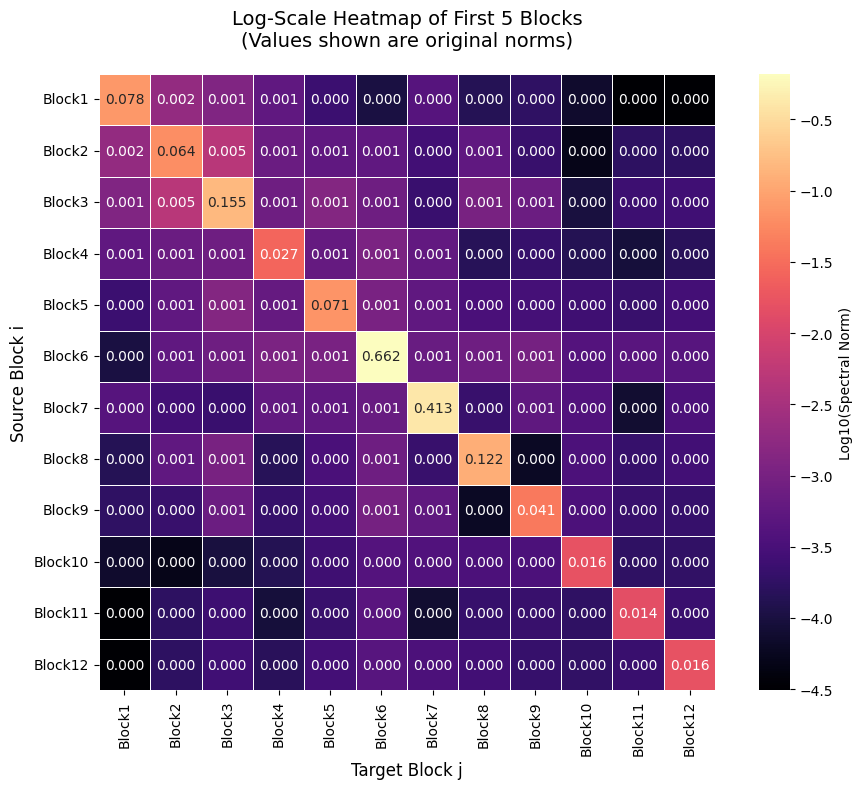


MATRIX SYMMETRY ANALYSIS
Symmetric part Frobenius norm: 0.8158
Antisymmetric part Frobenius norm: 0.0000
Total Frobenius norm: 0.8158
Symmetry ratio (sym/total): 1.0000
Maximum asymmetry: 0.000001
Matrix is not symmetric (max diff = 0.000001).

Saving results for first 5 blocks...
Results saved to 'results_first_12_1_norm/' directory.


In [ ]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM
from torch.utils.data import DataLoader
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os

# --- Основной код с использованием AdaGramFR для первых 5 блоков ---
def main():
    # Устройство
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Загрузка модели
    from model import GPT, GPTConfig  # nanoGPT's model.py

    ckpt_path = "path/to/ckpt.pt"
    checkpoint = torch.load(ckpt_path, map_location="cpu")

    config = GPTConfig(**checkpoint["model_args"])
    model = GPT(config)
    model.load_state_dict(checkpoint["model"])
    model.to(device)
    model.eval()

    # Получаем только первые 5 трансформерных блоков
    transformer_blocks = model.transformer.h[:12]
    num_blocks = len(transformer_blocks)
    print(f"Analyzing first {num_blocks} transformer blocks.")

    # Собираем информацию о размерах параметров каждого блока
    block_param_shapes = []
    block_param_sizes = []
    total_params = 0
    
    for block_idx, block in enumerate(transformer_blocks):
        # Собираем все параметры блока
        block_params = []
        for name, param in block.named_parameters():
            if param.requires_grad:
                block_params.append(param)
        
        # Вычисляем общее количество параметров в блоке
        block_size = sum(p.numel() for p in block_params)
        block_param_sizes.append(block_size)
        total_params += block_size
        
        # Сохраняем информацию о форме параметров
        shapes = [p.shape for p in block_params]
        block_param_shapes.append(shapes)
    
    print(f"Total parameters in first {num_blocks} blocks: {total_params:,}")
    print("Block sizes:", block_param_sizes)

    # Подготовка данных
    print("Loading dataset...")
    dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train[:50]")
    
    def tokenize_function(examples):
        return tokenizer(examples['text'], truncation=True, padding='max_length', max_length=128)
    
    tokenized_dataset = dataset.map(
        tokenize_function,
        batched=True,
        remove_columns=dataset.column_names
    )
    
    tokenized_dataset.set_format(type='torch', columns=['input_ids'])
    dataloader = DataLoader(tokenized_dataset, batch_size=1, shuffle=False)

    # Инициализация одного оптимизатора AdaGramFR для первых 5 блоков
    print("Initializing AdaGramFR optimizer for first 5 blocks...")
    
    # Создаем один фиктивный параметр, содержащий все параметры первых 5 блоков
    fake_param = torch.nn.Parameter(
        torch.zeros(total_params, device=device, dtype=torch.float32),
        requires_grad=True
    )
    
    # Инициализируем AdaGramFR с рангом 2
    ada_gram_fr = AdaGramFR(
        [fake_param],
        lr=0.00001,  # Не обновляем параметры, только накапливаем статистику
        eps=1e-4,
        weight_decay=0,
        max_rank=2,  # Ранг 2, как требуется
        task="First5BlocksAnalysis",
        enable_logging=False,
        save_matrix=False
    )

    # Обработка данных для накопления информации Фишера
    print("Processing batches to accumulate Fisher information...")
    total_examples = min(50, len(tokenized_dataset))
    
    for batch_idx, batch in enumerate(tqdm(dataloader, desc="Processing batches", total=total_examples)):
        if batch_idx >= total_examples:
            break
            
        input_ids = batch['input_ids'].to(device)
        
        # Прямой проход
        model.zero_grad()
        outputs = model(input_ids=input_ids, labels=input_ids)
        loss = outputs.loss
        
        # Обратное распространение
        loss.backward()
        
        # Собираем градиенты только первых 5 блоков в один вектор
        all_grads = []
        for block_idx, block in enumerate(transformer_blocks):
            for param in block.parameters():
                if param.grad is not None:
                    # Добавляем градиент в вектор
                    all_grads.append(param.grad.detach().flatten().to(torch.float32))
        
        # Объединяем все градиенты в один вектор
        if all_grads:
            full_grad_vector = torch.cat(all_grads)
            
            # Устанавливаем градиент для фиктивного параметра
            fake_param.grad = full_grad_vector
            
            # Выполняем шаг оптимизатора для накопления P и Q
            ada_gram_fr.step()
        
        # Очистка градиентов модели и фиктивного параметра
        model.zero_grad()
        fake_param.grad = None

    # Извлекаем матрицы P и Q из оптимизатора
    print("Extracting P and Q matrices from AdaGramFR...")
    state = ada_gram_fr.state[fake_param]
    
    # Проверяем, есть ли P и Q в состоянии
    if "P" in state and "Q" in state:
        P_full = state["P"].clone()
        Q_full = state["Q"].clone()
        current_rank = P_full.shape[1] if P_full.dim() > 1 else 1
        print(f"Full P shape: {P_full.shape}, Full Q shape: {Q_full.shape}")
        print(f"Current rank: {current_rank}")
    else:
        print("Warning: P and Q matrices not found in optimizer state.")
        # Создаем нулевые матрицы
        P_full = torch.zeros((total_params, 2), device=device)
        Q_full = torch.zeros((total_params, 2), device=device)
        current_rank = 0

    # Разделяем матрицы P и Q на блоки по первым 5 трансформерным блокам
    print("Splitting P and Q into blocks (first 5 blocks)...")
    P_blocks = []
    Q_blocks = []
    
    start_idx = 0
    for block_idx, block_size in enumerate(block_param_sizes):
        end_idx = start_idx + block_size
        P_block = P_full[start_idx:end_idx, :]
        Q_block = Q_full[start_idx:end_idx, :]
        
        P_blocks.append(P_block)
        Q_blocks.append(Q_block)
        
        print(f"Block {block_idx+1}: size={block_size}, P_block shape={P_block.shape}, Q_block shape={Q_block.shape}")
        
        start_idx = end_idx

    # Вычисляем попарные нормы произведений блоков: ||P_i Q_j^T|| = ||Q_j^T P_i||
    print("Computing pairwise block spectral norms for first 5 blocks...")
    block_norms = torch.zeros((num_blocks, num_blocks), device=device)
    
    for i in tqdm(range(num_blocks), desc="Computing norms"):
        P_i = P_blocks[i]  # (d_i, rank)
        
        for j in range(num_blocks):
            Q_j = Q_blocks[j]  # (d_j, rank)
            
            # Вычисляем Q_j^T @ P_i (размер rank x rank)
            if P_i.shape[0] > 0 and Q_j.shape[0] > 0 and current_rank > 0:
                try:
                    # Q_j^T имеет размер (rank, d_j), P_i имеет размер (d_i, rank)
                    Q_j_T = Q_j.T
                    
                    # Проверяем размерности
                    if Q_j_T.dim() == 1:
                        Q_j_T = Q_j_T.unsqueeze(0)
                    if P_i.dim() == 1:
                        P_i = P_i.unsqueeze(1)
                    
                    small_matrix = torch.matmul(Q_j_T, P_i)
                    
                    # Вычисляем спектральную норму (наибольшее сингулярное значение)
                    if small_matrix.numel() > 0:
                        # u, s, vh = torch.linalg.svd(small_matrix, full_matrices=False)
                        # spectral_norm = s[0].item() if len(s) > 0 else 0.0
                        spectral_norm = torch.linalg.norm(small_matrix).item()
                    else:
                        spectral_norm = 0.0
                    
                    block_norms[i, j] = spectral_norm
                except Exception as e:
                    print(f"Error computing norm for blocks {i+1}, {j+1}: {e}")
                    block_norms[i, j] = 0.0
            else:
                block_norms[i, j] = 0.0

    # Преобразуем в numpy для визуализации
    block_norms_np = block_norms.cpu().numpy()

    

    # Построение heatmap для первых 5 блоков
    print("Generating heatmap visualization for first 5 blocks...")
    plt.figure(figsize=(10, 8))
    
    ax = sns.heatmap(
        block_norms_np,
        annot=True,  # Включаем аннотации для маленькой матрицы
        fmt=".3f",   # Формат чисел с тремя знаками после запятой
        cmap='viridis',
        square=True,
        xticklabels=[f'Block{i+1}' for i in range(num_blocks)],
        yticklabels=[f'Block{i+1}' for i in range(num_blocks)],
        cbar_kws={'label': f'Spectral Norm ||Q_j^T P_i||₂ (Rank {current_rank})'},
        linewidths=0.5,
        linecolor='white'
    )
    
    plt.title(f'Pairwise Spectral Norms of First 5 Transformer Blocks\n(AdaGramFR Rank {current_rank})', 
              fontsize=16, pad=20)
    plt.xlabel('Target Block j', fontsize=14, labelpad=10)
    plt.ylabel('Source Block i', fontsize=14, labelpad=10)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    # Добавляем сетку
    ax.set_xticks(np.arange(num_blocks) + 0.5, minor=True)
    ax.set_yticks(np.arange(num_blocks) + 0.5, minor=True)
    ax.grid(which='minor', color='white', linestyle='-', linewidth=0.5)
    
    plt.tight_layout()
    
    # Сохраняем изображение
    os.makedirs('results_first_12_1_norm', exist_ok=True)
    np.savez('results_first_12_1_norm/matrix.npz', matrix=block_norms_np)
    plt.savefig(f'results_first_12_1_norm/first5_blocks_heatmap_rank{current_rank}.png', 
                dpi=300, bbox_inches='tight')
    plt.show()

    # Анализ диагональных элементов (внутриблочная информация)
    diag_norms = np.diag(block_norms_np)
    
    plt.figure(figsize=(10, 6))
    plt.bar(range(1, num_blocks+1), diag_norms, color='steelblue', alpha=0.8)
    plt.title(f'Diagonal Block Norms for First 5 Blocks\n(Within-Block Fisher Information, Rank {current_rank})', fontsize=14)
    plt.xlabel('Block', fontsize=12)
    plt.ylabel('Spectral Norm ||Q_i^T P_i||₂', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7, axis='y')
    plt.xticks(range(1, num_blocks+1))
    
    # Добавляем значения поверх столбцов
    for i, v in enumerate(diag_norms):
        plt.text(i+1, v + 0.01 * max(diag_norms), f'{v:.4f}', 
                 ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(f'results_first_12_1_norm/first5_diagonal_norms_rank{current_rank}.png', dpi=300)
    plt.show()

    # Вывод статистики
    print("\n" + "="*50)
    print(f"BLOCK NORM STATISTICS FOR FIRST 5 BLOCKS (Rank {current_rank})")
    print("="*50)
    print(f"Total blocks: {num_blocks}")
    print(f"Max norm: {block_norms_np.max():.4f}")
    print(f"Min norm: {block_norms_np.min():.4f}")
    print(f"Mean norm: {block_norms_np.mean():.4f}")
    print(f"Diagonal mean norm: {diag_norms.mean():.4f}")
    
    if num_blocks > 1:
        off_diag_sum = block_norms_np.sum() - diag_norms.sum()
        off_diag_mean = off_diag_sum / (num_blocks * (num_blocks - 1))
        print(f"Off-diagonal mean norm: {off_diag_mean:.4f}")
    
    print("-"*50)
    print("Diagonal norms per block:")
    for i, norm in enumerate(diag_norms):
        print(f"Block {i+1:2d}: {norm:.6e}")

    # Анализ взаимодействия между блоками
    print("\n" + "="*50)
    print("BLOCK INTERACTION ANALYSIS (First 5 Blocks)")
    print("="*50)
    
    # Находим самые сильные взаимодействия
    if num_blocks > 1:
        # Создаем копию для верхнего треугольника
        upper_triangle = np.triu(block_norms_np, k=1)
        if upper_triangle.sum() > 0:
            max_idx = np.unravel_index(np.argmax(upper_triangle), upper_triangle.shape)
            print(f"Strongest inter-block interaction: Block {max_idx[0]+1} → Block {max_idx[1]+1} with norm {upper_triangle[max_idx]:.4f}")
        
        # Находим самые слабые ненулевые взаимодействия
        lower_triangle = np.tril(block_norms_np, k=-1)
        non_zero_vals = lower_triangle[lower_triangle > 0]
        if len(non_zero_vals) > 0:
            min_val = non_zero_vals.min()
            min_idx = np.where(lower_triangle == min_val)
            if len(min_idx[0]) > 0:
                print(f"Weakest inter-block interaction: Block {min_idx[0][0]+1} → Block {min_idx[1][0]+1} with norm {min_val:.4f}")
    
    # Среднее взаимодействие для каждого блока
    row_means = block_norms_np.mean(axis=1)
    col_means = block_norms_np.mean(axis=0)
    
    print("\nAverage outgoing interaction per block (row means):")
    for i, mean_val in enumerate(row_means):
        print(f"Block {i+1:2d}: {mean_val:.4f}")
    
    print("\nAverage incoming interaction per block (column means):")
    for i, mean_val in enumerate(col_means):
        print(f"Block {i+1:2d}: {mean_val:.4f}")

    # Дополнительный анализ: тепловая карта с логарифмической шкалой
    print("\nGenerating log-scale heatmap...")
    log_block_norms = np.log10(block_norms_np + 1e-10)  # Добавляем маленькое значение, чтобы избежать log(0)
    
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(
        log_block_norms,
        annot=block_norms_np,  # Аннотируем оригинальными значениями
        fmt=".3f",
        cmap='magma',
        square=True,
        xticklabels=[f'Block{i+1}' for i in range(num_blocks)],
        yticklabels=[f'Block{i+1}' for i in range(num_blocks)],
        cbar_kws={'label': 'Log10(Spectral Norm)'},
        linewidths=0.5,
        linecolor='white'
    )
    
    plt.title(f'Log-Scale Heatmap of First 5 Blocks\n(Values shown are original norms)', 
              fontsize=14, pad=20)
    plt.xlabel('Target Block j', fontsize=12)
    plt.ylabel('Source Block i', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'results_first_12_1_norm/first5_log_heatmap_rank{current_rank}.png', dpi=300)
    plt.show()

    # Анализ симметрии матрицы
    print("\n" + "="*50)
    print("MATRIX SYMMETRY ANALYSIS")
    print("="*50)
    
    # Вычисляем симметричную и антисимметричную части
    symmetric_part = (block_norms_np + block_norms_np.T) / 2
    antisymmetric_part = (block_norms_np - block_norms_np.T) / 2
    
    sym_norm = np.linalg.norm(symmetric_part, 'fro')
    antisym_norm = np.linalg.norm(antisymmetric_part, 'fro')
    total_norm = np.linalg.norm(block_norms_np, 'fro')
    
    print(f"Symmetric part Frobenius norm: {sym_norm:.4f}")
    print(f"Antisymmetric part Frobenius norm: {antisym_norm:.4f}")
    print(f"Total Frobenius norm: {total_norm:.4f}")
    print(f"Symmetry ratio (sym/total): {sym_norm/total_norm:.4f}")
    
    # Проверка на симметричность
    symmetry_diff = np.abs(block_norms_np - block_norms_np.T).max()
    print(f"Maximum asymmetry: {symmetry_diff:.6f}")
    if symmetry_diff < 1e-10:
        print("Matrix is symmetric (within tolerance).")
    else:
        print(f"Matrix is not symmetric (max diff = {symmetry_diff:.6f}).")

    # Сохраняем данные для дальнейшего анализа
    print("\nSaving results for first 5 blocks...")
    results = {
        'block_norms': block_norms_np,
        'diag_norms': diag_norms,
        'block_sizes': block_param_sizes,
        'P_blocks': [p.cpu().numpy() for p in P_blocks],
        'Q_blocks': [q.cpu().numpy() for q in Q_blocks],
        'current_rank': current_rank,
        'num_blocks': num_blocks,
        'row_means': row_means,
        'col_means': col_means
    }
    
    os.makedirs('results_first_12_1_norm', exist_ok=True)
    np.savez('results_first_12_1_norm/first5_blocks_analysis.npz', **results)
    
    # Сохраняем текстовый отчет
    with open('results_first_12_1_norm/analysis_report.txt', 'w') as f:
        f.write("="*50 + "\n")
        f.write(f"ANALYSIS REPORT FOR FIRST 5 TRANSFORMER BLOCKS\n")
        f.write("="*50 + "\n\n")
        
        f.write(f"Total blocks analyzed: {num_blocks}\n")
        f.write(f"Total parameters: {total_params:,}\n")
        f.write(f"AdaGramFR rank: {current_rank}\n\n")
        
        f.write("Block sizes:\n")
        for i, size in enumerate(block_param_sizes):
            f.write(f"  Block {i+1}: {size:,} parameters\n")
        
        f.write("\nDiagonal norms (within-block):\n")
        for i, norm in enumerate(diag_norms):
            f.write(f"  Block {i+1}: {norm:.6e}\n")
        
        f.write(f"\nDiagonal mean: {diag_norms.mean():.6e}\n")
        if num_blocks > 1:
            off_diag_mean = (block_norms_np.sum() - diag_norms.sum()) / (num_blocks * (num_blocks - 1))
            f.write(f"Off-diagonal mean: {off_diag_mean:.6e}\n")
            f.write(f"Diagonal/Off-diagonal ratio: {diag_norms.mean()/off_diag_mean:.4f}\n")
    
    print("Results saved to 'results_first_12_1_norm/' directory.")

if __name__ == "__main__":
    main()

Using device: cuda
Loading model...
Analyzing first 12 transformer blocks.
Total parameters in first 12 blocks: 151,154,688
Block sizes: [12596224, 12596224, 12596224, 12596224, 12596224, 12596224, 12596224, 12596224, 12596224, 12596224, 12596224, 12596224]
Loading dataset...
Initializing AdaGramFR optimizer for first 5 blocks...
Processing batches to accumulate Fisher information...


Processing batches: 100%|██████████| 50/50 [01:05<00:00,  1.30s/it]


Extracting P and Q matrices from AdaGramFR...
Full P shape: torch.Size([151154688, 2]), Full Q shape: torch.Size([151154688, 2])
Current rank: 2
Splitting P and Q into blocks (first 5 blocks)...
Block 1: size=12596224, P_block shape=torch.Size([12596224, 2]), Q_block shape=torch.Size([12596224, 2])
Block 2: size=12596224, P_block shape=torch.Size([12596224, 2]), Q_block shape=torch.Size([12596224, 2])
Block 3: size=12596224, P_block shape=torch.Size([12596224, 2]), Q_block shape=torch.Size([12596224, 2])
Block 4: size=12596224, P_block shape=torch.Size([12596224, 2]), Q_block shape=torch.Size([12596224, 2])
Block 5: size=12596224, P_block shape=torch.Size([12596224, 2]), Q_block shape=torch.Size([12596224, 2])
Block 6: size=12596224, P_block shape=torch.Size([12596224, 2]), Q_block shape=torch.Size([12596224, 2])
Block 7: size=12596224, P_block shape=torch.Size([12596224, 2]), Q_block shape=torch.Size([12596224, 2])
Block 8: size=12596224, P_block shape=torch.Size([12596224, 2]), Q_blo

Computing norms: 100%|██████████| 12/12 [00:01<00:00,  9.14it/s]


Generating heatmap visualization for first 5 blocks...


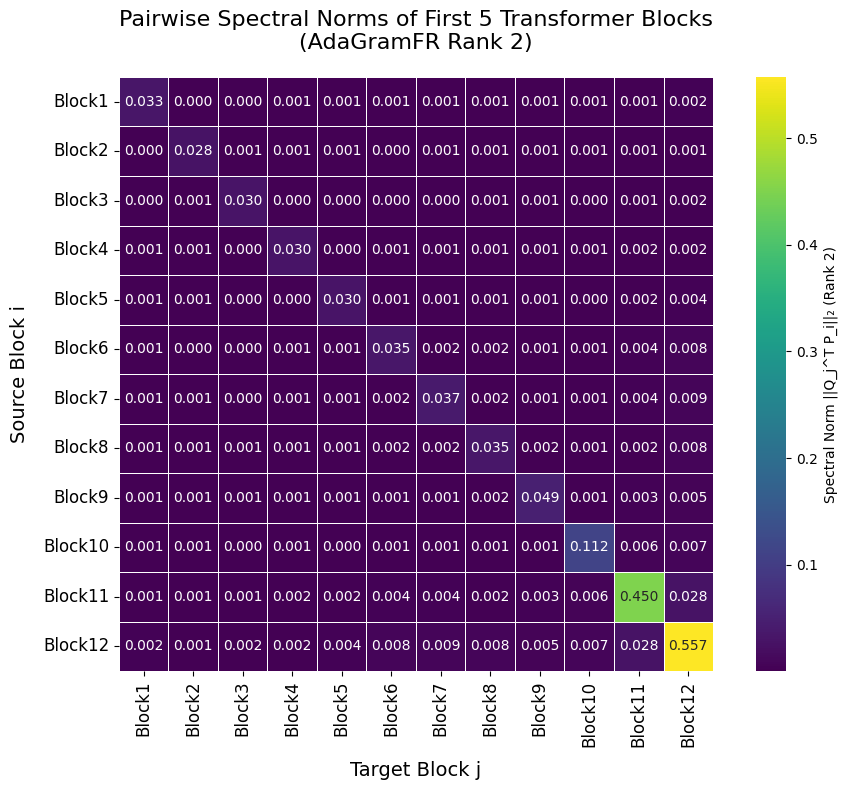

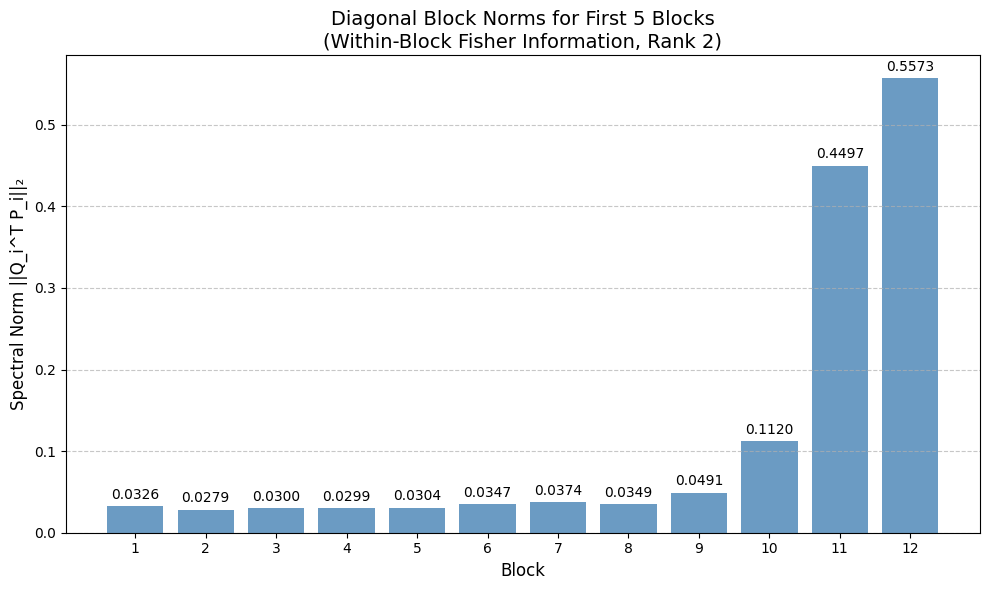


BLOCK NORM STATISTICS FOR FIRST 5 BLOCKS (Rank 2)
Total blocks: 12
Max norm: 0.5573
Min norm: 0.0002
Mean norm: 0.0118
Diagonal mean norm: 0.1188
Off-diagonal mean norm: 0.0021
--------------------------------------------------
Diagonal norms per block:
Block  1: 3.258945e-02
Block  2: 2.790911e-02
Block  3: 3.004248e-02
Block  4: 2.987258e-02
Block  5: 3.038146e-02
Block  6: 3.472431e-02
Block  7: 3.743409e-02
Block  8: 3.485274e-02
Block  9: 4.905026e-02
Block 10: 1.119878e-01
Block 11: 4.496746e-01
Block 12: 5.573434e-01

BLOCK INTERACTION ANALYSIS (First 5 Blocks)
Strongest inter-block interaction: Block 11 → Block 12 with norm 0.0279
Weakest inter-block interaction: Block 6 → Block 3 with norm 0.0002

Average outgoing interaction per block (row means):
Block  1: 0.0034
Block  2: 0.0030
Block  3: 0.0031
Block  4: 0.0033
Block  5: 0.0037
Block  6: 0.0046
Block  7: 0.0049
Block  8: 0.0046
Block  9: 0.0055
Block 10: 0.0111
Block 11: 0.0419
Block 12: 0.0527

Average incoming interacti

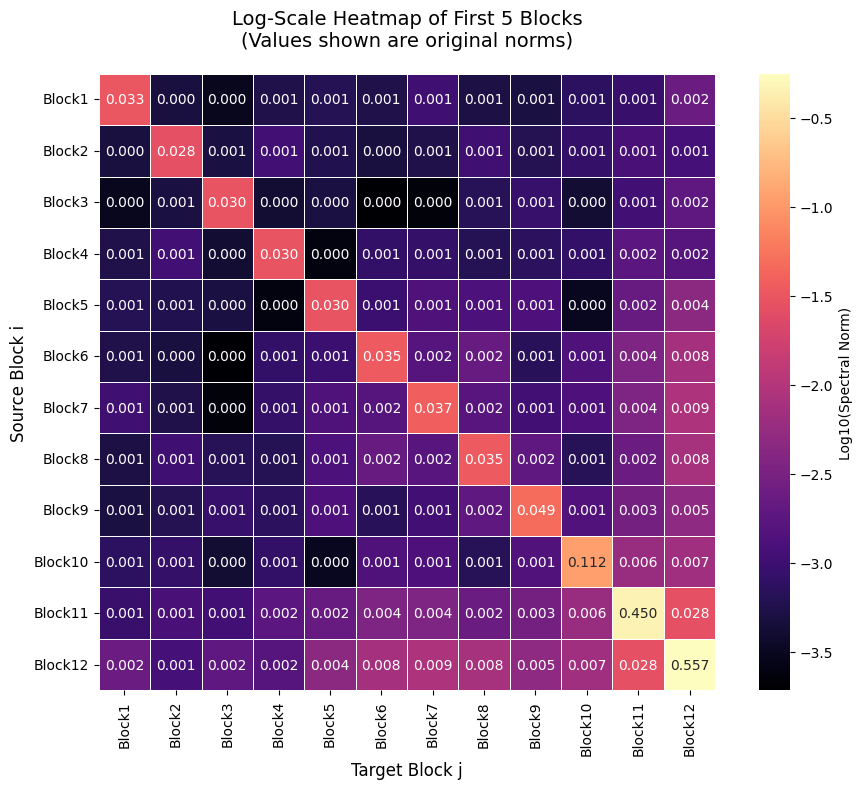


MATRIX SYMMETRY ANALYSIS
Symmetric part Frobenius norm: 0.7339
Antisymmetric part Frobenius norm: 0.0000
Total Frobenius norm: 0.7339
Symmetry ratio (sym/total): 1.0000
Maximum asymmetry: 0.000002
Matrix is not symmetric (max diff = 0.000002).

Saving results for first 5 blocks...
Results saved to 'results_second_12_2_norm' directory.


In [4]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM
from torch.utils.data import DataLoader
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os

# --- Основной код с использованием AdaGramFR для первых 5 блоков ---
def main():
    # Устройство
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Загрузка модели
    model_name = "EleutherAI/pythia-410m"
    print("Loading model...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.pad_token = tokenizer.eos_token
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float16 if device.type == 'cuda' else torch.float32,
        low_cpu_mem_usage=True
    ).to(device)
    model.eval()

    # Получаем только первые 5 трансформерных блоков
    transformer_blocks = model.gpt_neox.layers[12:24]  # Берем только первые 5 блоков
    num_blocks = len(transformer_blocks)
    print(f"Analyzing first {num_blocks} transformer blocks.")

    # Собираем информацию о размерах параметров каждого блока
    block_param_shapes = []
    block_param_sizes = []
    total_params = 0
    
    for block_idx, block in enumerate(transformer_blocks):
        # Собираем все параметры блока
        block_params = []
        for name, param in block.named_parameters():
            if param.requires_grad:
                block_params.append(param)
        
        # Вычисляем общее количество параметров в блоке
        block_size = sum(p.numel() for p in block_params)
        block_param_sizes.append(block_size)
        total_params += block_size
        
        # Сохраняем информацию о форме параметров
        shapes = [p.shape for p in block_params]
        block_param_shapes.append(shapes)
    
    print(f"Total parameters in first {num_blocks} blocks: {total_params:,}")
    print("Block sizes:", block_param_sizes)

    # Подготовка данных
    print("Loading dataset...")
    dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train[:50]")
    
    def tokenize_function(examples):
        return tokenizer(examples['text'], truncation=True, padding='max_length', max_length=128)
    
    tokenized_dataset = dataset.map(
        tokenize_function,
        batched=True,
        remove_columns=dataset.column_names
    )
    
    tokenized_dataset.set_format(type='torch', columns=['input_ids'])
    dataloader = DataLoader(tokenized_dataset, batch_size=1, shuffle=False)

    # Инициализация одного оптимизатора AdaGramFR для первых 5 блоков
    print("Initializing AdaGramFR optimizer for first 5 blocks...")
    
    # Создаем один фиктивный параметр, содержащий все параметры первых 5 блоков
    fake_param = torch.nn.Parameter(
        torch.zeros(total_params, device=device, dtype=torch.float32),
        requires_grad=True
    )
    
    # Инициализируем AdaGramFR с рангом 2
    ada_gram_fr = AdaGramFR(
        [fake_param],
        lr=0.00001,  # Не обновляем параметры, только накапливаем статистику
        eps=1e-4,
        weight_decay=0,
        max_rank=2,  # Ранг 2, как требуется
        task="First5BlocksAnalysis",
        enable_logging=False,
        save_matrix=False
    )

    # Обработка данных для накопления информации Фишера
    print("Processing batches to accumulate Fisher information...")
    total_examples = min(50, len(tokenized_dataset))
    
    for batch_idx, batch in enumerate(tqdm(dataloader, desc="Processing batches", total=total_examples)):
        if batch_idx >= total_examples:
            break
            
        input_ids = batch['input_ids'].to(device)
        
        # Прямой проход
        model.zero_grad()
        outputs = model(input_ids=input_ids, labels=input_ids)
        loss = outputs.loss
        
        # Обратное распространение
        loss.backward()
        
        # Собираем градиенты только первых 5 блоков в один вектор
        all_grads = []
        for block_idx, block in enumerate(transformer_blocks):
            for param in block.parameters():
                if param.grad is not None:
                    # Добавляем градиент в вектор
                    all_grads.append(param.grad.detach().flatten().to(torch.float32))
        
        # Объединяем все градиенты в один вектор
        if all_grads:
            full_grad_vector = torch.cat(all_grads)
            
            # Устанавливаем градиент для фиктивного параметра
            fake_param.grad = full_grad_vector
            
            # Выполняем шаг оптимизатора для накопления P и Q
            ada_gram_fr.step()
        
        # Очистка градиентов модели и фиктивного параметра
        model.zero_grad()
        fake_param.grad = None

    # Извлекаем матрицы P и Q из оптимизатора
    print("Extracting P and Q matrices from AdaGramFR...")
    state = ada_gram_fr.state[fake_param]
    
    # Проверяем, есть ли P и Q в состоянии
    if "P" in state and "Q" in state:
        P_full = state["P"].clone()
        Q_full = state["Q"].clone()
        current_rank = P_full.shape[1] if P_full.dim() > 1 else 1
        print(f"Full P shape: {P_full.shape}, Full Q shape: {Q_full.shape}")
        print(f"Current rank: {current_rank}")
    else:
        print("Warning: P and Q matrices not found in optimizer state.")
        # Создаем нулевые матрицы
        P_full = torch.zeros((total_params, 2), device=device)
        Q_full = torch.zeros((total_params, 2), device=device)
        current_rank = 0

    # Разделяем матрицы P и Q на блоки по первым 5 трансформерным блокам
    print("Splitting P and Q into blocks (first 5 blocks)...")
    P_blocks = []
    Q_blocks = []
    
    start_idx = 0
    for block_idx, block_size in enumerate(block_param_sizes):
        end_idx = start_idx + block_size
        P_block = P_full[start_idx:end_idx, :]
        Q_block = Q_full[start_idx:end_idx, :]
        
        P_blocks.append(P_block)
        Q_blocks.append(Q_block)
        
        print(f"Block {block_idx+1}: size={block_size}, P_block shape={P_block.shape}, Q_block shape={Q_block.shape}")
        
        start_idx = end_idx

    # Вычисляем попарные нормы произведений блоков: ||P_i Q_j^T|| = ||Q_j^T P_i||
    print("Computing pairwise block spectral norms for first 5 blocks...")
    block_norms = torch.zeros((num_blocks, num_blocks), device=device)
    
    for i in tqdm(range(num_blocks), desc="Computing norms"):
        P_i = P_blocks[i]  # (d_i, rank)
        
        for j in range(num_blocks):
            Q_j = Q_blocks[j]  # (d_j, rank)
            
            # Вычисляем Q_j^T @ P_i (размер rank x rank)
            if P_i.shape[0] > 0 and Q_j.shape[0] > 0 and current_rank > 0:
                try:
                    # Q_j^T имеет размер (rank, d_j), P_i имеет размер (d_i, rank)
                    Q_j_T = Q_j.T
                    
                    # Проверяем размерности
                    if Q_j_T.dim() == 1:
                        Q_j_T = Q_j_T.unsqueeze(0)
                    if P_i.dim() == 1:
                        P_i = P_i.unsqueeze(1)
                    
                    small_matrix = torch.matmul(Q_j_T, P_i)
                    
                    # Вычисляем спектральную норму (наибольшее сингулярное значение)
                    if small_matrix.numel() > 0:
                        # u, s, vh = torch.linalg.svd(small_matrix, full_matrices=False)
                        # spectral_norm = s[0].item() if len(s) > 0 else 0.0
                        spectral_norm = torch.linalg.norm(small_matrix).item()
                    else:
                        spectral_norm = 0.0
                    
                    block_norms[i, j] = spectral_norm
                except Exception as e:
                    print(f"Error computing norm for blocks {i+1}, {j+1}: {e}")
                    block_norms[i, j] = 0.0
            else:
                block_norms[i, j] = 0.0

    # Преобразуем в numpy для визуализации
    block_norms_np = block_norms.cpu().numpy()


    # Построение heatmap для первых 5 блоков
    print("Generating heatmap visualization for first 5 blocks...")
    plt.figure(figsize=(10, 8))
    
    ax = sns.heatmap(
        block_norms_np,
        annot=True,  # Включаем аннотации для маленькой матрицы
        fmt=".3f",   # Формат чисел с тремя знаками после запятой
        cmap='viridis',
        square=True,
        xticklabels=[f'Block{i+1}' for i in range(num_blocks)],
        yticklabels=[f'Block{i+1}' for i in range(num_blocks)],
        cbar_kws={'label': f'Spectral Norm ||Q_j^T P_i||₂ (Rank {current_rank})'},
        linewidths=0.5,
        linecolor='white'
    )
    
    plt.title(f'Pairwise Spectral Norms of First 5 Transformer Blocks\n(AdaGramFR Rank {current_rank})', 
              fontsize=16, pad=20)
    plt.xlabel('Target Block j', fontsize=14, labelpad=10)
    plt.ylabel('Source Block i', fontsize=14, labelpad=10)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    # Добавляем сетку
    ax.set_xticks(np.arange(num_blocks) + 0.5, minor=True)
    ax.set_yticks(np.arange(num_blocks) + 0.5, minor=True)
    ax.grid(which='minor', color='white', linestyle='-', linewidth=0.5)
    
    plt.tight_layout()
    
    # Сохраняем изображение
    os.makedirs('results_second_12_2_norm', exist_ok=True)
    np.savez('results_second_12_2_norm/matrix.npz', matrix=block_norms_np)
    plt.savefig(f'results_second_12_2_norm/first5_blocks_heatmap_rank{current_rank}.png', 
                dpi=300, bbox_inches='tight')
    plt.show()

    # Анализ диагональных элементов (внутриблочная информация)
    diag_norms = np.diag(block_norms_np)
    
    plt.figure(figsize=(10, 6))
    plt.bar(range(1, num_blocks+1), diag_norms, color='steelblue', alpha=0.8)
    plt.title(f'Diagonal Block Norms for First 5 Blocks\n(Within-Block Fisher Information, Rank {current_rank})', fontsize=14)
    plt.xlabel('Block', fontsize=12)
    plt.ylabel('Spectral Norm ||Q_i^T P_i||₂', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7, axis='y')
    plt.xticks(range(1, num_blocks+1))
    
    # Добавляем значения поверх столбцов
    for i, v in enumerate(diag_norms):
        plt.text(i+1, v + 0.01 * max(diag_norms), f'{v:.4f}', 
                 ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(f'results_second_12_2_norm/first5_diagonal_norms_rank{current_rank}.png', dpi=300)
    plt.show()

    # Вывод статистики
    print("\n" + "="*50)
    print(f"BLOCK NORM STATISTICS FOR FIRST 5 BLOCKS (Rank {current_rank})")
    print("="*50)
    print(f"Total blocks: {num_blocks}")
    print(f"Max norm: {block_norms_np.max():.4f}")
    print(f"Min norm: {block_norms_np.min():.4f}")
    print(f"Mean norm: {block_norms_np.mean():.4f}")
    print(f"Diagonal mean norm: {diag_norms.mean():.4f}")
    
    if num_blocks > 1:
        off_diag_sum = block_norms_np.sum() - diag_norms.sum()
        off_diag_mean = off_diag_sum / (num_blocks * (num_blocks - 1))
        print(f"Off-diagonal mean norm: {off_diag_mean:.4f}")
    
    print("-"*50)
    print("Diagonal norms per block:")
    for i, norm in enumerate(diag_norms):
        print(f"Block {i+1:2d}: {norm:.6e}")

    # Анализ взаимодействия между блоками
    print("\n" + "="*50)
    print("BLOCK INTERACTION ANALYSIS (First 5 Blocks)")
    print("="*50)
    
    # Находим самые сильные взаимодействия
    if num_blocks > 1:
        # Создаем копию для верхнего треугольника
        upper_triangle = np.triu(block_norms_np, k=1)
        if upper_triangle.sum() > 0:
            max_idx = np.unravel_index(np.argmax(upper_triangle), upper_triangle.shape)
            print(f"Strongest inter-block interaction: Block {max_idx[0]+1} → Block {max_idx[1]+1} with norm {upper_triangle[max_idx]:.4f}")
        
        # Находим самые слабые ненулевые взаимодействия
        lower_triangle = np.tril(block_norms_np, k=-1)
        non_zero_vals = lower_triangle[lower_triangle > 0]
        if len(non_zero_vals) > 0:
            min_val = non_zero_vals.min()
            min_idx = np.where(lower_triangle == min_val)
            if len(min_idx[0]) > 0:
                print(f"Weakest inter-block interaction: Block {min_idx[0][0]+1} → Block {min_idx[1][0]+1} with norm {min_val:.4f}")
    
    # Среднее взаимодействие для каждого блока
    row_means = block_norms_np.mean(axis=1)
    col_means = block_norms_np.mean(axis=0)
    
    print("\nAverage outgoing interaction per block (row means):")
    for i, mean_val in enumerate(row_means):
        print(f"Block {i+1:2d}: {mean_val:.4f}")
    
    print("\nAverage incoming interaction per block (column means):")
    for i, mean_val in enumerate(col_means):
        print(f"Block {i+1:2d}: {mean_val:.4f}")

    # Дополнительный анализ: тепловая карта с логарифмической шкалой
    print("\nGenerating log-scale heatmap...")
    log_block_norms = np.log10(block_norms_np + 1e-10)  # Добавляем маленькое значение, чтобы избежать log(0)
    
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(
        log_block_norms,
        annot=block_norms_np,  # Аннотируем оригинальными значениями
        fmt=".3f",
        cmap='magma',
        square=True,
        xticklabels=[f'Block{i+1}' for i in range(num_blocks)],
        yticklabels=[f'Block{i+1}' for i in range(num_blocks)],
        cbar_kws={'label': 'Log10(Spectral Norm)'},
        linewidths=0.5,
        linecolor='white'
    )
    
    plt.title(f'Log-Scale Heatmap of First 5 Blocks\n(Values shown are original norms)', 
              fontsize=14, pad=20)
    plt.xlabel('Target Block j', fontsize=12)
    plt.ylabel('Source Block i', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'results_second_12_2_norm/first5_log_heatmap_rank{current_rank}.png', dpi=300)
    plt.show()

    # Анализ симметрии матрицы
    print("\n" + "="*50)
    print("MATRIX SYMMETRY ANALYSIS")
    print("="*50)
    
    # Вычисляем симметричную и антисимметричную части
    symmetric_part = (block_norms_np + block_norms_np.T) / 2
    antisymmetric_part = (block_norms_np - block_norms_np.T) / 2
    
    sym_norm = np.linalg.norm(symmetric_part, 'fro')
    antisym_norm = np.linalg.norm(antisymmetric_part, 'fro')
    total_norm = np.linalg.norm(block_norms_np, 'fro')
    
    print(f"Symmetric part Frobenius norm: {sym_norm:.4f}")
    print(f"Antisymmetric part Frobenius norm: {antisym_norm:.4f}")
    print(f"Total Frobenius norm: {total_norm:.4f}")
    print(f"Symmetry ratio (sym/total): {sym_norm/total_norm:.4f}")
    
    # Проверка на симметричность
    symmetry_diff = np.abs(block_norms_np - block_norms_np.T).max()
    print(f"Maximum asymmetry: {symmetry_diff:.6f}")
    if symmetry_diff < 1e-10:
        print("Matrix is symmetric (within tolerance).")
    else:
        print(f"Matrix is not symmetric (max diff = {symmetry_diff:.6f}).")

    # Сохраняем данные для дальнейшего анализа
    print("\nSaving results for first 5 blocks...")
    results = {
        'block_norms': block_norms_np,
        'diag_norms': diag_norms,
        'block_sizes': block_param_sizes,
        'P_blocks': [p.cpu().numpy() for p in P_blocks],
        'Q_blocks': [q.cpu().numpy() for q in Q_blocks],
        'current_rank': current_rank,
        'num_blocks': num_blocks,
        'row_means': row_means,
        'col_means': col_means
    }
    
    os.makedirs('results_second_12_2_norm', exist_ok=True)
    np.savez('results_second_12_2_norm/first5_blocks_analysis.npz', **results)
    
    # Сохраняем текстовый отчет
    with open('results_second_12_2_norm/analysis_report.txt', 'w') as f:
        f.write("="*50 + "\n")
        f.write(f"ANALYSIS REPORT FOR FIRST 5 TRANSFORMER BLOCKS\n")
        f.write("="*50 + "\n\n")
        
        f.write(f"Total blocks analyzed: {num_blocks}\n")
        f.write(f"Total parameters: {total_params:,}\n")
        f.write(f"AdaGramFR rank: {current_rank}\n\n")
        
        f.write("Block sizes:\n")
        for i, size in enumerate(block_param_sizes):
            f.write(f"  Block {i+1}: {size:,} parameters\n")
        
        f.write("\nDiagonal norms (within-block):\n")
        for i, norm in enumerate(diag_norms):
            f.write(f"  Block {i+1}: {norm:.6e}\n")
        
        f.write(f"\nDiagonal mean: {diag_norms.mean():.6e}\n")
        if num_blocks > 1:
            off_diag_mean = (block_norms_np.sum() - diag_norms.sum()) / (num_blocks * (num_blocks - 1))
            f.write(f"Off-diagonal mean: {off_diag_mean:.6e}\n")
            f.write(f"Diagonal/Off-diagonal ratio: {diag_norms.mean()/off_diag_mean:.4f}\n")
    
    print("Results saved to 'results_second_12_2_norm' directory.")

if __name__ == "__main__":
    main()

In [ ]:

import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForMaskedLM
from torch.utils.data import DataLoader
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os

# --- Основной код с использованием AdaGramFR для первых 5 блоков BERT ---
def main():
    # Устройство
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Загрузка модели BERT-base-uncased
    model_name = "bert-base-uncased"
    print(f"Loading BERT model: {model_name}")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    # Загружаем модель для Masked Language Modeling
    model = AutoModelForMaskedLM.from_pretrained(
        model_name,
        torch_dtype=torch.float16 if device.type == 'cuda' else torch.float32,
        output_hidden_states=True,
        output_attentions=False
    ).to(device)
    model.eval()

    # Получаем только первые 5 трансформерных блоков BERT
    # В BERT трансформерные блоки находятся в model.bert.encoder.layer
    transformer_blocks = model.bert.encoder.layer[:12]  # Берем только первые 5 блоков
    num_blocks = len(transformer_blocks)
    print(f"BERT has {len(model.bert.encoder.layer)} total layers.")
    print(f"Analyzing first {num_blocks} transformer blocks.")

    # Собираем информацию о размерах параметров каждого блока
    block_param_shapes = []
    block_param_sizes = []
    total_params = 0
    
    for block_idx, block in enumerate(transformer_blocks):
        # Собираем все параметры блока
        block_params = []
        for name, param in block.named_parameters():
            if param.requires_grad:
                block_params.append(param)
        
        # Вычисляем общее количество параметров в блоке
        block_size = sum(p.numel() for p in block_params)
        block_param_sizes.append(block_size)
        total_params += block_size
        
        # Сохраняем информацию о форме параметров
        shapes = [p.shape for p in block_params]
        block_param_shapes.append(shapes)
    
    print(f"Total parameters in first {num_blocks} blocks: {total_params:,}")
    print("Block sizes:", block_param_sizes)

    # Подготовка данных для BERT
    print("Loading dataset...")
    dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train[:50]")
    
    def tokenize_function(examples):
        # BERT токенизатор требует специального форматирования
        return tokenizer(
            examples['text'],
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'
        )
    
    tokenized_dataset = dataset.map(
        tokenize_function,
        batched=True,
        remove_columns=dataset.column_names
    )
    
    # Для BERT нам нужны input_ids и attention_mask
    tokenized_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask'])
    dataloader = DataLoader(tokenized_dataset, batch_size=1, shuffle=False)

    # Инициализация одного оптимизатора AdaGramFR для первых 5 блоков
    print("Initializing AdaGramFR optimizer for first 5 BERT blocks...")
    
    # Создаем один фиктивный параметр, содержащий все параметры первых 5 блоков
    fake_param = torch.nn.Parameter(
        torch.zeros(total_params, device=device, dtype=torch.float32),
        requires_grad=True
    )
    
    # Инициализируем AdaGramFR с рангом 2
    ada_gram_fr = AdaGramFR(
        [fake_param],
        lr=0.00001,  # Не обновляем параметры, только накапливаем статистику
        eps=1e-4,
        weight_decay=0,
        max_rank=2,  # Ранг 2, как требуется
        task="BERT_First5BlocksAnalysis",
        enable_logging=False,
        save_matrix=False
    )

    # Обработка данных для накопления информации Фишера
    print("Processing batches to accumulate Fisher information...")
    total_examples = min(50, len(tokenized_dataset))
    
    for batch_idx, batch in enumerate(tqdm(dataloader, desc="Processing batches", total=total_examples)):
        if batch_idx >= total_examples:
            break
            
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        # Для BERT создаем случайные маски для задачи MLM
        # Создаем labels (такие же как input_ids для задачи MLM)
        labels = input_ids.clone()
        
        # Создаем маску для случайных токенов (15% токенов)
        mask_prob = 0.15
        special_tokens_mask = [
            tokenizer.get_special_tokens_mask(val, already_has_special_tokens=True) 
            for val in labels.tolist()
        ]
        special_tokens_mask = torch.tensor(special_tokens_mask, dtype=torch.bool, device=device)
        
        # Случайно маскируем токены
        probability_matrix = torch.full(labels.shape, mask_prob, device=device)
        probability_matrix.masked_fill_(special_tokens_mask, value=0.0)
        masked_indices = torch.bernoulli(probability_matrix).bool()
        
        # Заменяем маскированные токены на [MASK] (103 - это token_id для [MASK] в BERT)
        input_ids[masked_indices] = tokenizer.mask_token_id
        
        # Прямой проход с masked language modeling
        model.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss
        
        # Обратное распространение
        loss.backward()
        
        # Собираем градиенты только первых 5 блоков в один вектор
        all_grads = []
        for block_idx, block in enumerate(transformer_blocks):
            for param in block.parameters():
                if param.grad is not None:
                    # Добавляем градиент в вектор
                    all_grads.append(param.grad.detach().flatten().to(torch.float32))
        
        # Объединяем все градиенты в один вектор
        if all_grads:
            full_grad_vector = torch.cat(all_grads)
            
            # Устанавливаем градиент для фиктивного параметра
            fake_param.grad = full_grad_vector
            
            # Выполняем шаг оптимизатора для накопления P и Q
            ada_gram_fr.step()
        
        # Очистка градиентов модели и фиктивного параметра
        model.zero_grad()
        fake_param.grad = None

    # Извлекаем матрицы P и Q из оптимизатора
    print("Extracting P and Q matrices from AdaGramFR...")
    state = ada_gram_fr.state[fake_param]
    
    # Проверяем, есть ли P и Q в состоянии
    if "P" in state and "Q" in state:
        P_full = state["P"].clone()
        Q_full = state["Q"].clone()
        current_rank = P_full.shape[1] if P_full.dim() > 1 else 1
        print(f"Full P shape: {P_full.shape}, Full Q shape: {Q_full.shape}")
        print(f"Current rank: {current_rank}")
    else:
        print("Warning: P and Q matrices not found in optimizer state.")
        # Создаем нулевые матрицы
        P_full = torch.zeros((total_params, 2), device=device)
        Q_full = torch.zeros((total_params, 2), device=device)
        current_rank = 0

    # Разделяем матрицы P и Q на блоки по первым 5 трансформерным блокам
    print("Splitting P and Q into blocks (first 5 BERT blocks)...")
    P_blocks = []
    Q_blocks = []
    
    start_idx = 0
    for block_idx, block_size in enumerate(block_param_sizes):
        end_idx = start_idx + block_size
        P_block = P_full[start_idx:end_idx, :]
        Q_block = Q_full[start_idx:end_idx, :]
        
        P_blocks.append(P_block)
        Q_blocks.append(Q_block)
        
        print(f"Block {block_idx+1}: size={block_size:,}, P_block shape={P_block.shape}, Q_block shape={Q_block.shape}")
        
        start_idx = end_idx

    # Вычисляем попарные нормы произведений блоков: ||P_i Q_j^T|| = ||Q_j^T P_i||
    print("Computing pairwise block spectral norms for first 5 BERT blocks...")
    block_norms = torch.zeros((num_blocks, num_blocks), device=device)
    
    for i in tqdm(range(num_blocks), desc="Computing norms"):
        P_i = P_blocks[i]  # (d_i, rank)
        
        for j in range(num_blocks):
            Q_j = Q_blocks[j]  # (d_j, rank)
            
            # Вычисляем Q_j^T @ P_i (размер rank x rank)
            if P_i.shape[0] > 0 and Q_j.shape[0] > 0 and current_rank > 0:
                try:
                    # Q_j^T имеет размер (rank, d_j), P_i имеет размер (d_i, rank)
                    Q_j_T = Q_j.T
                    
                    # Проверяем размерности
                    if Q_j_T.dim() == 1:
                        Q_j_T = Q_j_T.unsqueeze(0)
                    if P_i.dim() == 1:
                        P_i = P_i.unsqueeze(1)
                    
                    small_matrix = torch.matmul(Q_j_T, P_i)
                    
                    # Вычисляем спектральную норму (наибольшее сингулярное значение)
                    if small_matrix.numel() > 0:
                        u, s, vh = torch.linalg.svd(small_matrix, full_matrices=False)
                        spectral_norm = s[0].item() if len(s) > 0 else 0.0
                    else:
                        spectral_norm = 0.0
                    
                    block_norms[i, j] = spectral_norm
                except Exception as e:
                    print(f"Error computing norm for blocks {i+1}, {j+1}: {e}")
                    block_norms[i, j] = 0.0
            else:
                block_norms[i, j] = 0.0

    # Преобразуем в numpy для визуализации
    block_norms_np = block_norms.cpu().numpy()

    # Построение heatmap для первых 5 блоков
    print("Generating heatmap visualization for first 12 blocks...")
    plt.figure(figsize=(10, 8))
    
    ax = sns.heatmap(
        block_norms_np,
        annot=True,  # Включаем аннотации для маленькой матрицы
        fmt=".3f",   # Формат чисел с тремя знаками после запятой
        cmap='viridis',
        square=True,
        xticklabels=[f'Block{i+1}' for i in range(num_blocks)],
        yticklabels=[f'Block{i+1}' for i in range(num_blocks)],
        cbar_kws={'label': f'Spectral Norm ||Q_j^T P_i||₂ (Rank {current_rank})'},
        linewidths=0.5,
        linecolor='white'
    )
    
    plt.title(f'Pairwise Spectral Norms of First 5 Transformer Blocks\n(AdaGramFR Rank {current_rank})', 
              fontsize=16, pad=20)
    plt.xlabel('Target Block j', fontsize=14, labelpad=10)
    plt.ylabel('Source Block i', fontsize=14, labelpad=10)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    # Добавляем сетку
    ax.set_xticks(np.arange(num_blocks) + 0.5, minor=True)
    ax.set_yticks(np.arange(num_blocks) + 0.5, minor=True)
    ax.grid(which='minor', color='white', linestyle='-', linewidth=0.5)
    
    plt.tight_layout()
    
    # Сохраняем изображение
    os.makedirs('results_bert', exist_ok=True)
    plt.savefig(f'results_bert/first5_blocks_heatmap_rank{current_rank}.png', 
                dpi=300, bbox_inches='tight')
    plt.show()

    

    # Анализ диагональных элементов (внутриблочная информация)
    diag_norms = np.diag(block_norms_np)
    
    plt.figure(figsize=(10, 6))
    plt.bar(range(1, num_blocks+1), diag_norms, color='steelblue', alpha=0.8)
    plt.title(f'Diagonal Block Norms for First 5 Blocks\n(Within-Block Fisher Information, Rank {current_rank})', fontsize=14)
    plt.xlabel('Block', fontsize=12)
    plt.ylabel('Spectral Norm ||Q_i^T P_i||₂', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7, axis='y')
    plt.xticks(range(1, num_blocks+1))
    
    # Добавляем значения поверх столбцов
    for i, v in enumerate(diag_norms):
        plt.text(i+1, v + 0.01 * max(diag_norms), f'{v:.4f}', 
                 ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(f'results_bert/first5_diagonal_norms_rank{current_rank}.png', dpi=300)
    plt.show()

    # Вывод статистики
    print("\n" + "="*50)
    print(f"BLOCK NORM STATISTICS FOR FIRST 5 BLOCKS (Rank {current_rank})")
    print("="*50)
    print(f"Total blocks: {num_blocks}")
    print(f"Max norm: {block_norms_np.max():.4f}")
    print(f"Min norm: {block_norms_np.min():.4f}")
    print(f"Mean norm: {block_norms_np.mean():.4f}")
    print(f"Diagonal mean norm: {diag_norms.mean():.4f}")
    
    if num_blocks > 1:
        off_diag_sum = block_norms_np.sum() - diag_norms.sum()
        off_diag_mean = off_diag_sum / (num_blocks * (num_blocks - 1))
        print(f"Off-diagonal mean norm: {off_diag_mean:.4f}")
    
    print("-"*50)
    print("Diagonal norms per block:")
    for i, norm in enumerate(diag_norms):
        print(f"Block {i+1:2d}: {norm:.6e}")

    # Анализ взаимодействия между блоками
    print("\n" + "="*50)
    print("BLOCK INTERACTION ANALYSIS (First 5 Blocks)")
    print("="*50)
    
    # Находим самые сильные взаимодействия
    if num_blocks > 1:
        # Создаем копию для верхнего треугольника
        upper_triangle = np.triu(block_norms_np, k=1)
        if upper_triangle.sum() > 0:
            max_idx = np.unravel_index(np.argmax(upper_triangle), upper_triangle.shape)
            print(f"Strongest inter-block interaction: Block {max_idx[0]+1} → Block {max_idx[1]+1} with norm {upper_triangle[max_idx]:.4f}")
        
        # Находим самые слабые ненулевые взаимодействия
        lower_triangle = np.tril(block_norms_np, k=-1)
        non_zero_vals = lower_triangle[lower_triangle > 0]
        if len(non_zero_vals) > 0:
            min_val = non_zero_vals.min()
            min_idx = np.where(lower_triangle == min_val)
            if len(min_idx[0]) > 0:
                print(f"Weakest inter-block interaction: Block {min_idx[0][0]+1} → Block {min_idx[1][0]+1} with norm {min_val:.4f}")
    
    # Среднее взаимодействие для каждого блока
    row_means = block_norms_np.mean(axis=1)
    col_means = block_norms_np.mean(axis=0)
    
    print("\nAverage outgoing interaction per block (row means):")
    for i, mean_val in enumerate(row_means):
        print(f"Block {i+1:2d}: {mean_val:.4f}")
    
    print("\nAverage incoming interaction per block (column means):")
    for i, mean_val in enumerate(col_means):
        print(f"Block {i+1:2d}: {mean_val:.4f}")

    # Дополнительный анализ: тепловая карта с логарифмической шкалой
    print("\nGenerating log-scale heatmap...")
    log_block_norms = np.log10(block_norms_np + 1e-10)  # Добавляем маленькое значение, чтобы избежать log(0)
    
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(
        log_block_norms,
        annot=block_norms_np,  # Аннотируем оригинальными значениями
        fmt=".3f",
        cmap='magma',
        square=True,
        xticklabels=[f'Block{i+1}' for i in range(num_blocks)],
        yticklabels=[f'Block{i+1}' for i in range(num_blocks)],
        cbar_kws={'label': 'Log10(Spectral Norm)'},
        linewidths=0.5,
        linecolor='white'
    )
    
    plt.title(f'Log-Scale Heatmap of First 5 Blocks\n(Values shown are original norms)', 
              fontsize=14, pad=20)
    plt.xlabel('Target Block j', fontsize=12)
    plt.ylabel('Source Block i', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'results_bert/first5_log_heatmap_rank{current_rank}.png', dpi=300)
    plt.show()

    # Анализ симметрии матрицы
    print("\n" + "="*50)
    print("MATRIX SYMMETRY ANALYSIS")
    print("="*50)
    
    # Вычисляем симметричную и антисимметричную части
    symmetric_part = (block_norms_np + block_norms_np.T) / 2
    antisymmetric_part = (block_norms_np - block_norms_np.T) / 2
    
    sym_norm = np.linalg.norm(symmetric_part, 'fro')
    antisym_norm = np.linalg.norm(antisymmetric_part, 'fro')
    total_norm = np.linalg.norm(block_norms_np, 'fro')
    
    print(f"Symmetric part Frobenius norm: {sym_norm:.4f}")
    print(f"Antisymmetric part Frobenius norm: {antisym_norm:.4f}")
    print(f"Total Frobenius norm: {total_norm:.4f}")
    print(f"Symmetry ratio (sym/total): {sym_norm/total_norm:.4f}")
    
    # Проверка на симметричность
    symmetry_diff = np.abs(block_norms_np - block_norms_np.T).max()
    print(f"Maximum asymmetry: {symmetry_diff:.6f}")
    if symmetry_diff < 1e-10:
        print("Matrix is symmetric (within tolerance).")
    else:
        print(f"Matrix is not symmetric (max diff = {symmetry_diff:.6f}).")

    # Сохраняем данные для дальнейшего анализа
    print("\nSaving results for first 5 blocks...")
    results = {
        'block_norms': block_norms_np,
        'diag_norms': diag_norms,
        'block_sizes': block_param_sizes,
        'P_blocks': [p.cpu().numpy() for p in P_blocks],
        'Q_blocks': [q.cpu().numpy() for q in Q_blocks],
        'current_rank': current_rank,
        'num_blocks': num_blocks,
        'row_means': row_means,
        'col_means': col_means
    }
    
    os.makedirs('results_bert', exist_ok=True)
    np.savez('results_bert/first5_blocks_analysis.npz', **results)
    
    # Сохраняем текстовый отчет
    with open('results_bert/analysis_report.txt', 'w') as f:
        f.write("="*50 + "\n")
        f.write(f"ANALYSIS REPORT FOR FIRST 5 TRANSFORMER BLOCKS\n")
        f.write("="*50 + "\n\n")
        
        f.write(f"Total blocks analyzed: {num_blocks}\n")
        f.write(f"Total parameters: {total_params:,}\n")
        f.write(f"AdaGramFR rank: {current_rank}\n\n")
        
        f.write("Block sizes:\n")
        for i, size in enumerate(block_param_sizes):
            f.write(f"  Block {i+1}: {size:,} parameters\n")
        
        f.write("\nDiagonal norms (within-block):\n")
        for i, norm in enumerate(diag_norms):
            f.write(f"  Block {i+1}: {norm:.6e}\n")
        
        f.write(f"\nDiagonal mean: {diag_norms.mean():.6e}\n")
        if num_blocks > 1:
            off_diag_mean = (block_norms_np.sum() - diag_norms.sum()) / (num_blocks * (num_blocks - 1))
            f.write(f"Off-diagonal mean: {off_diag_mean:.6e}\n")
            f.write(f"Diagonal/Off-diagonal ratio: {diag_norms.mean()/off_diag_mean:.4f}\n")
    
    print("Results saved to 'results_first5/' directory.")

if __name__ == "__main__":
    main()





    

Using device: cuda
Loading BERT model: bert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


BERT has 12 total layers.
Analyzing first 12 transformer blocks.
Total parameters in first 12 blocks: 85,054,464
Block sizes: [7087872, 7087872, 7087872, 7087872, 7087872, 7087872, 7087872, 7087872, 7087872, 7087872, 7087872, 7087872]
Loading dataset...


Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Initializing AdaGramFR optimizer for first 5 BERT blocks...
Processing batches to accumulate Fisher information...


Processing batches:  94%|█████████▍| 47/50 [00:34<00:02,  1.30it/s]

In [4]:
def plot_blocks_and_singular_values(P_blocks, Q_blocks,
                                   num_blocks, current_rank,
                                   out_dir, max_blocks=6):
    """
    2-row figure:
      Row 1: core matrices M_bb = Q_b^T P_b (rank x rank)
      Row 2: singular values of each M_bb

    Big layout + large fonts for readability.
    """
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    os.makedirs(out_dir, exist_ok=True)

    n_plot = min(max_blocks, num_blocks)
    if n_plot <= 0 or current_rank <= 0:
        print(f"Nothing to plot: n_plot={n_plot}, rank={current_rank}")
        return

    # ---- global style ----
    plt.rcParams.update({
        "font.size": 22,
        "axes.titlesize": 26,
        "axes.labelsize": 22,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        "legend.fontsize": 20,
    })

    # Big canvas: width grows with number of blocks
    W = 8.5 * n_plot   # 7 inches per block column
    H = 14.0           # total height
    fig, axes = plt.subplots(2, n_plot, figsize=(W, H))

    if n_plot == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    # ---- Row 1: core matrices ----
    for i in range(n_plot):
        b = i
        M = (Q_blocks[b].T @ P_blocks[b]).detach().cpu().numpy()

        ax = axes[0, i]
        sns.heatmap(
            M,
            annot=True if current_rank <= 8 else False,
            fmt=".2f",
            cmap="vlag",
            square=True,
            ax=ax,
            cbar=(i == n_plot - 1),
            cbar_kws={"shrink": 0.8}
        )
        ax.set_title(f"Block {b+1}: core $Q^T P$ (r={current_rank})")
        ax.set_xlabel("rank comp.")
        ax.set_ylabel("rank comp.")

    # ---- Row 2: singular values ----
    for i in range(n_plot):
        b = i
        M = (Q_blocks[b].T @ P_blocks[b]).detach().cpu().numpy()
        s = np.linalg.svd(M, compute_uv=False)

        ax = axes[1, i]
        ax.plot(np.arange(1, len(s) + 1), s, marker="o", linewidth=3)
        ax.set_title(f"Block {b+1}: singular values")
        ax.set_xlabel("Index")
        ax.set_ylabel("Singular value")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.set_xticks(np.arange(1, len(s) + 1))

    plt.tight_layout()
    out_path = os.path.join(out_dir, f"blocks_core_and_svals_rank{current_rank}_big.png")
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)


In [2]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
# os.environ["TORCH_USE_CUDA_DSA"] = "1"  # optional, requires restart

import torch
import numpy as np
from torch.utils.data import DataLoader
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import tiktoken

# from your AdaGramFR implementation
# from adagram_optimizers.AdagramSVD import AdaGramFR
# from adagram_optimizers.AdagramPS import AdaGramFR
from adagram_optimizers.AdamGram import AdamGram

# from nanoGPT repo
from model import GPT, GPTConfig


def make_xy_from_text(text: str, vocab_size: int, block_size: int, device, enc):
    """
    nanoGPT-style: encode text -> clamp to vocab -> truncate to block_size+1 -> shift to x,y.
    Same logic as your make_batch_from_text(). 
    """
    ids = enc.encode(text)
    ids = [min(max(int(t), 0), vocab_size - 1) for t in ids]
    ids = ids[: block_size + 1]  # +1 for shift

    if len(ids) < 2:
        # ensure at least one token in x and y
        ids = ids + [0]

    x = torch.tensor(ids[:-1], dtype=torch.long, device=device)[None, :]  # (1, T)
    y = torch.tensor(ids[1:],  dtype=torch.long, device=device)[None, :]  # (1, T)
    return x, y



device = torch.device("cpu")
print(f"Using device: {device}")
# ----------------- load nanoGPT checkpoint -----------------
# ckpt_path = "out-sgd/5000_ckpt.pt"
# ckpt_path = "out_muonwithadamw_bs16_lr1e-3/5000_ckpt.pt"
# ckpt_path = "out_adamw_bs16_lr1e-4/5000_ckpt.pt"
ckpt_path = "out_adagramps_bs512_lr1e-2_rank1/5000_ckpt.pt"



print(f"Loading nanoGPT checkpoint from {ckpt_path}...")
checkpoint = torch.load(ckpt_path, map_location="cpu", weights_only=False)
# Build model from model_args (nanoGPT style)
config = GPTConfig(**checkpoint["model_args"])
if hasattr(config, "flash"):
    config.flash = False
model = GPT(config)
# Strip _orig_mod. prefix (torch.compile artifact)
sd = checkpoint["model"] if "model" in checkpoint else checkpoint
sd = {k.replace("_orig_mod.", ""): v for k, v in sd.items()}
# strict=False ignores extra keys like attn.bias
model.load_state_dict(sd, strict=False)
model.to(device)
model.eval()
# ----------------- tokenizer / encoding (nanoGPT-style) -----------------
enc = tiktoken.get_encoding("gpt2")  # same as nanoGPT prepare.py uses [web:112]
vocab_size = int(checkpoint["model_args"]["vocab_size"])
model_block_size = int(checkpoint["model_args"]["block_size"])
block_size = min(128, model_block_size)
print(f"Checkpoint vocab_size={vocab_size}, block_size={model_block_size}, using T={block_size}")
# ----------------- select transformer blocks -----------------
num_layers_to_analyze = 6  # your setting
transformer_blocks = model.transformer.h[:num_layers_to_analyze]
num_blocks = len(transformer_blocks)
print(f"Analyzing first {num_blocks} transformer blocks.")
# ----------------- collect param sizes per block -----------------
block_param_sizes = []
total_params = 0
for block in transformer_blocks:
    block_size_params = sum(p.numel() for p in block.parameters() if p.requires_grad)
    block_param_sizes.append(block_size_params)
    total_params += block_size_params
print(f"Total parameters in first {num_blocks} blocks: {total_params:,}")
print("Block sizes:", block_param_sizes)
# ----------------- dataset + dataloader -----------------
print("Loading dataset...")
dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train[:50]")
# Keep raw text; we'll encode with tiktoken ourselves
dataset = dataset.filter(lambda x: isinstance(x["text"], str) and len(x["text"].strip()) > 0)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)
# ----------------- fake param + AdaGramFR -----------------
print("Initializing AdaGramFR optimizer for first blocks...")
fake_param = torch.nn.Parameter(
    torch.zeros(total_params, device=device, dtype=torch.float32),
    requires_grad=True,
)
ada_gram_fr = AdamGram(
    [fake_param],
    lr=1e-5,
    eps=1e-4,
    weight_decay=0,
    max_rank=5,
    task="FirstBlocksAnalysis",
    enable_logging=False,
    save_matrix=False,
)
# ----------------- accumulate Fisher-style info -----------------
print("Processing batches to accumulate Fisher information...")
total_examples = min(50, len(dataset))
for batch_idx, batch in enumerate(tqdm(dataloader, desc="Processing batches", total=total_examples)):
    if batch_idx >= total_examples:
        break
    text = batch["text"][0]  # batch_size=1
    x, y = make_xy_from_text(text, vocab_size=vocab_size, block_size=block_size, device=device, enc=enc)
    model.zero_grad(set_to_none=True)
    # Depending on your nanoGPT model.py, ONE of these will work:
    # 1) karpathy nanoGPT: logits, loss = model(x, y)
    # logits, loss = model(x, y)
    # 2) your variant (you previously used targets=)
    logits, loss = model(x, targets=y)
    loss.backward()
    all_grads = []
    for block in transformer_blocks:
        for p in block.parameters():
            if p.grad is not None:
                all_grads.append(p.grad.detach().flatten().to(torch.float32))
    if all_grads:
        full_grad_vector = torch.cat(all_grads)
        if full_grad_vector.numel() != total_params:
            raise ValueError(f"Gradient length {full_grad_vector.numel()} != total_params {total_params}")
        fake_param.grad = full_grad_vector
        ada_gram_fr.step()
    model.zero_grad(set_to_none=True)
    fake_param.grad = None
# ----------------- extract P, Q -----------------
print("Extracting P and Q matrices from AdaGramFR...")
state = ada_gram_fr.state[fake_param]
if "P" in state and "Q" in state:
    P_full = state["P"].clone()
    Q_full = state["Q"].clone()
    current_rank = P_full.shape[1] if P_full.dim() > 1 else 1
    print(f"Full P shape: {P_full.shape}, Full Q shape: {Q_full.shape}")
    print(f"Current rank: {current_rank}")
else:
    print("Warning: P and Q matrices not found in optimizer state.")
    P_full = torch.zeros((total_params, 2), device=device)
    Q_full = torch.zeros((total_params, 2), device=device)
    current_rank = 0
# ----------------- split P, Q by blocks -----------------

print("Splitting P and Q into blocks...")
P_blocks, Q_blocks = [], []
start_idx = 0
for block_idx, bs in enumerate(block_param_sizes):
    end_idx = start_idx + bs
    P_blocks.append(P_full[start_idx:end_idx, :])
    Q_blocks.append(Q_full[start_idx:end_idx, :])
    print(f"Block {block_idx+1}: size={bs}, P={P_blocks[-1].shape}, Q={Q_blocks[-1].shape}")
    start_idx = end_idx
# ----------------- pairwise norms -----------------
print("Computing pairwise block spectral norms...")
block_norms = torch.zeros((num_blocks, num_blocks), device=device)
for i in tqdm(range(num_blocks), desc="Computing norms"):
    P_i = P_blocks[i]
    for j in range(num_blocks):
        Q_j = Q_blocks[j]
        if P_i.shape[0] > 0 and Q_j.shape[0] > 0 and current_rank > 0:
            small_matrix = Q_j.T @ P_i  # (rank, rank)
            block_norms[i, j] = torch.linalg.norm(small_matrix).item()  # Frobenius of rankxrank
block_norms_np = block_norms.cpu().numpy()
out_dir = "results_nanogpt_blocks"


Using device: cpu
Loading nanoGPT checkpoint from out_adagramps_bs512_lr1e-2_rank1/5000_ckpt.pt...
number of parameters: 10.65M
Checkpoint vocab_size=65, block_size=256, using T=128
Analyzing first 6 transformer blocks.
Total parameters in first 6 blocks: 10,621,440
Block sizes: [1770240, 1770240, 1770240, 1770240, 1770240, 1770240]
Loading dataset...
Initializing AdaGramFR optimizer for first blocks...
Processing batches to accumulate Fisher information...


Processing batches: 100%|██████████| 31/31 [04:09<00:00,  8.05s/it]


Extracting P and Q matrices from AdaGramFR...
Full P shape: torch.Size([10621440, 5]), Full Q shape: torch.Size([10621440, 5])
Current rank: 5
Splitting P and Q into blocks...
Block 1: size=1770240, P=torch.Size([1770240, 5]), Q=torch.Size([1770240, 5])
Block 2: size=1770240, P=torch.Size([1770240, 5]), Q=torch.Size([1770240, 5])
Block 3: size=1770240, P=torch.Size([1770240, 5]), Q=torch.Size([1770240, 5])
Block 4: size=1770240, P=torch.Size([1770240, 5]), Q=torch.Size([1770240, 5])
Block 5: size=1770240, P=torch.Size([1770240, 5]), Q=torch.Size([1770240, 5])
Block 6: size=1770240, P=torch.Size([1770240, 5]), Q=torch.Size([1770240, 5])
Computing pairwise block spectral norms...


Computing norms: 100%|██████████| 6/6 [00:00<00:00, 11.99it/s]


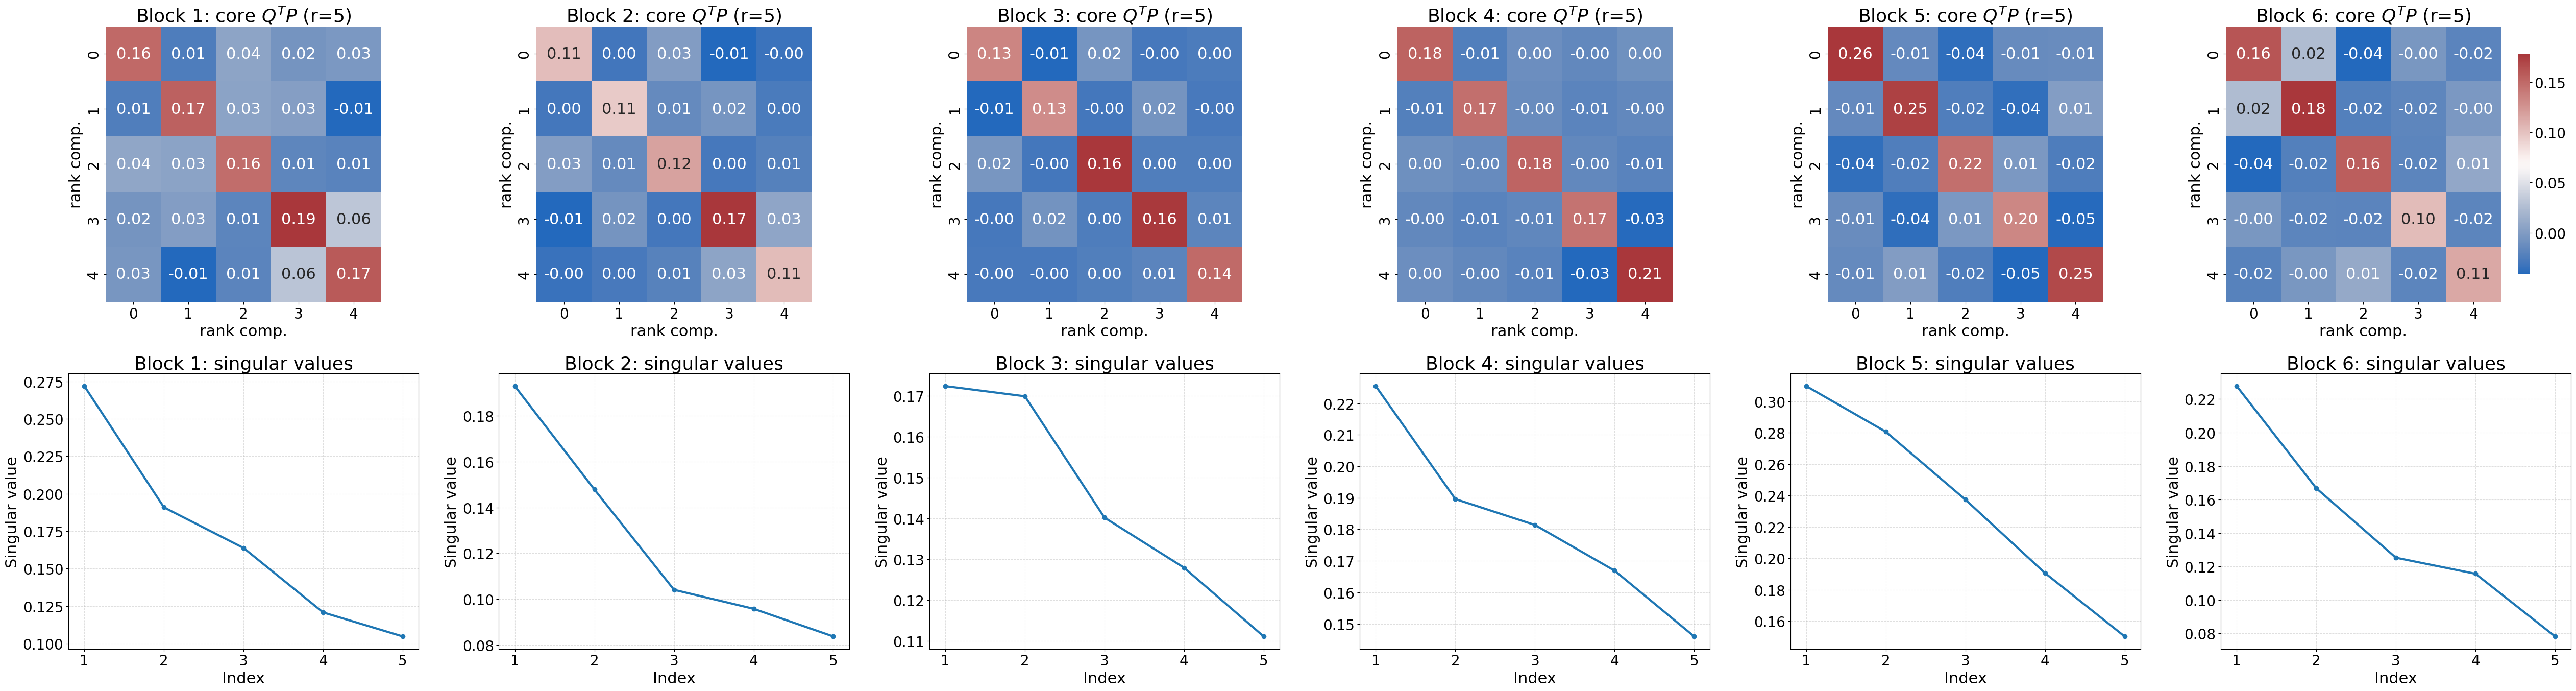

Saved: results_nanogpt_blocks/blocks_core_and_svals_rank5_big.png
Generating heatmap visualization...


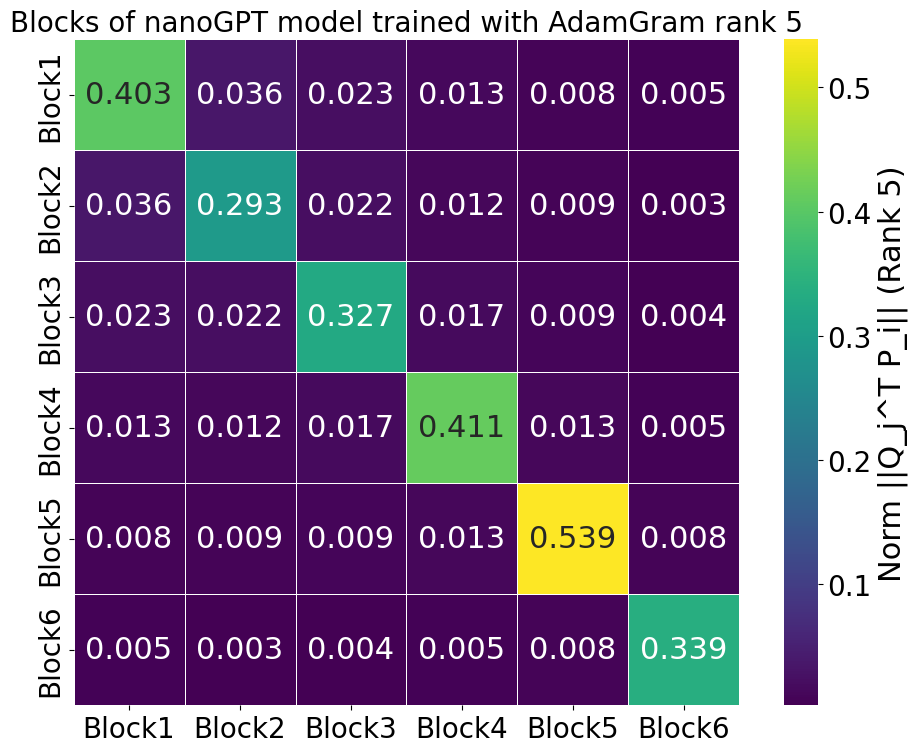

Diagonal mean norm: 0.385374
Off-diagonal mean norm: 0.012477
Results saved to 'results_nanogpt_blocks/' directory.


In [5]:

plot_blocks_and_singular_values(
P_blocks=P_blocks,
Q_blocks=Q_blocks,
num_blocks=num_blocks,
current_rank=current_rank,
out_dir=out_dir,
max_blocks=6,
)

# ----------------- plots + save -----------------
print("Generating heatmap visualization...")
out_dir = "results_nanogpt_blocks"
os.makedirs(out_dir, exist_ok=True)

plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    block_norms_np,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    square=True,
    xticklabels=[f"Block{i+1}" for i in range(num_blocks)],
    yticklabels=[f"Block{i+1}" for i in range(num_blocks)],
    cbar_kws={"label": f"Norm ||Q_j^T P_i|| (Rank {current_rank})"},
    linewidths=0.5,
    linecolor="white",
)
plt.title(f"Blocks of nanoGPT model trained with AdamGram rank 5", fontsize=20)
plt.tight_layout()
np.savez(os.path.join(out_dir, "matrix.npz"), matrix=block_norms_np)
plt.savefig(os.path.join(out_dir, f"blocks_heatmap_rank{current_rank}.png"), dpi=300, bbox_inches="tight")
plt.show()

diag_norms = np.diag(block_norms_np)
print(f"Diagonal mean norm: {diag_norms.mean():.6f}")
if num_blocks > 1:
    off_diag_mean = (block_norms_np.sum() - diag_norms.sum()) / (num_blocks * (num_blocks - 1))
    print(f"Off-diagonal mean norm: {off_diag_mean:.6f}")
print(f"Results saved to '{out_dir}/' directory.")


In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
# os.environ["TORCH_USE_CUDA_DSA"] = "1"  # optional, requires restart

import torch
import numpy as np
from torch.utils.data import DataLoader
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import tiktoken

from adagram_optimizers.AdamGram import AdamGram
from model import GPT, GPTConfig


def make_xy_from_text(text: str, vocab_size: int, block_size: int, device, enc):
    ids = enc.encode(text)
    ids = [min(max(int(t), 0), vocab_size - 1) for t in ids]
    ids = ids[: block_size + 1]
    if len(ids) < 2:
        ids = ids + [0]
    x = torch.tensor(ids[:-1], dtype=torch.long, device=device)[None, :]
    y = torch.tensor(ids[1:],  dtype=torch.long, device=device)[None, :]
    return x, y


# ----------------- NEW: define sub-blocks (parts) inside each transformer block -----------------
# Fine-grained split that matches your param names:
# transformer.h.<i>.ln_1.*, transformer.h.<i>.attn.c_attn.*, transformer.h.<i>.attn.c_proj.*,
# transformer.h.<i>.ln_2.*, transformer.h.<i>.mlp.c_fc.*, transformer.h.<i>.mlp.c_proj.*
SPLIT_MODE = "fine"  # "fine" or "coarse"

def iter_parts(block):
    if SPLIT_MODE == "coarse":
        return [
            ("ln_1", block.ln_1),
            ("attn", block.attn),
            ("ln_2", block.ln_2),
            ("mlp",  block.mlp),
        ]
    elif SPLIT_MODE == "fine":
        return [
            ("ln_1",        block.ln_1),
            ("attn.c_attn", block.attn.c_attn),
            ("attn.c_proj", block.attn.c_proj),
            ("ln_2",        block.ln_2),
            ("mlp.c_fc",    block.mlp.c_fc),
            ("mlp.c_proj",  block.mlp.c_proj),
        ]
    else:
        raise ValueError("SPLIT_MODE must be 'fine' or 'coarse'")

def flat_grads(module, device, dtype=torch.float32):
    """Deterministic: returns grad for every trainable param; zeros if grad is None."""
    out = []
    for p in module.parameters():
        if not p.requires_grad:
            continue
        if p.grad is None:
            out.append(torch.zeros(p.numel(), device=device, dtype=dtype))
        else:
            out.append(p.grad.detach().reshape(-1).to(dtype))
    return out


device = torch.device("cpu")
print(f"Using device: {device}")

# ----------------- load nanoGPT checkpoint -----------------
ckpt_path = "out_adagramps_bs512_lr1e-2_rank1/5000_ckpt.pt"

print(f"Loading nanoGPT checkpoint from {ckpt_path}...")
checkpoint = torch.load(ckpt_path, map_location="cpu", weights_only=False)

config = GPTConfig(**checkpoint["model_args"])
if hasattr(config, "flash"):
    config.flash = False

model = GPT(config)
sd = checkpoint["model"] if "model" in checkpoint else checkpoint
sd = {k.replace("_orig_mod.", ""): v for k, v in sd.items()}
model.load_state_dict(sd, strict=False)
model.to(device)
model.eval()

# ----------------- tokenizer / encoding -----------------
enc = tiktoken.get_encoding("gpt2")
vocab_size = int(checkpoint["model_args"]["vocab_size"])
model_block_size = int(checkpoint["model_args"]["block_size"])
block_size = min(128, model_block_size)
print(f"Checkpoint vocab_size={vocab_size}, block_size={model_block_size}, using T={block_size}")

# ----------------- select transformer blocks -----------------
num_layers_to_analyze = 6
transformer_blocks = model.transformer.h[:num_layers_to_analyze]
num_blocks = len(transformer_blocks)
print(f"Analyzing first {num_blocks} transformer blocks.")
print(f"Split mode: {SPLIT_MODE}")

# ----------------- NEW: precompute sizes/slices for each (block, part) in the flattened vector -----------------
part_meta = []  # list of dicts: block_idx, part_name, size, slice
cursor = 0
for bi, block in enumerate(transformer_blocks):
    for pname, pmod in iter_parts(block):
        n = sum(p.numel() for p in pmod.parameters() if p.requires_grad)
        part_meta.append(dict(block=bi, part=pname, size=n, sl=slice(cursor, cursor + n)))
        cursor += n

total_params = cursor
print(f"Total parameters across selected blocks+parts: {total_params:,}")
print("First few parts:", [(m["block"], m["part"], m["size"]) for m in part_meta[: min(10, len(part_meta))]])

# ----------------- dataset + dataloader -----------------
print("Loading dataset...")
dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train[:50]")
dataset = dataset.filter(lambda x: isinstance(x["text"], str) and len(x["text"].strip()) > 0)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

# ----------------- fake param + AdamGram -----------------
print("Initializing AdamGram optimizer...")
fake_param = torch.nn.Parameter(
    torch.zeros(total_params, device=device, dtype=torch.float32),
    requires_grad=True,
)

ada_gram_fr = AdamGram(
    [fake_param],
    lr=1e-5,
    eps=1e-4,
    weight_decay=0,
    max_rank=5,
    task=f"BlocksPartsAnalysis_{SPLIT_MODE}",
    enable_logging=False,
    save_matrix=False,
)

# ----------------- accumulate Fisher-style info -----------------
print("Processing batches to accumulate Fisher information...")
total_examples = min(50, len(dataset))

for batch_idx, batch in enumerate(tqdm(dataloader, desc="Processing batches", total=total_examples)):
    if batch_idx >= total_examples:
        break

    text = batch["text"][0]
    x, y = make_xy_from_text(text, vocab_size=vocab_size, block_size=block_size, device=device, enc=enc)

    model.zero_grad(set_to_none=True)
    logits, loss = model(x, targets=y)
    loss.backward()

    # NEW: deterministic concatenation, by (block, part), zeros for missing grads
    all_grads = []
    for block in transformer_blocks:
        for pname, pmod in iter_parts(block):
            all_grads.extend(flat_grads(pmod, device=device, dtype=torch.float32))

    full_grad_vector = torch.cat(all_grads) if all_grads else None
    if full_grad_vector is None or full_grad_vector.numel() != total_params:
        raise ValueError(f"Gradient length {None if full_grad_vector is None else full_grad_vector.numel()} != total_params {total_params}")

    fake_param.grad = full_grad_vector
    ada_gram_fr.step()

    model.zero_grad(set_to_none=True)
    fake_param.grad = None

# ----------------- extract P, Q -----------------
print("Extracting P and Q matrices...")
state = ada_gram_fr.state[fake_param]
if "P" in state and "Q" in state:
    P_full = state["P"].clone()
    Q_full = state["Q"].clone()
    current_rank = P_full.shape[1] if P_full.dim() > 1 else 1
    print(f"Full P shape: {tuple(P_full.shape)}, Full Q shape: {tuple(Q_full.shape)}, rank={current_rank}")
else:
    raise RuntimeError(f"P/Q not found in optimizer state keys={list(state.keys())}")

# ----------------- split P, Q by (block, part) -----------------
print("Splitting P and Q into (block, part) pieces...")
P_parts, Q_parts = {}, {}
for m in part_meta:
    key = (m["block"], m["part"])
    P_parts[key] = P_full[m["sl"], :]
    Q_parts[key] = Q_full[m["sl"], :]
    # optional verbose:
    # print(f"Block {m['block']} part {m['part']}: {P_parts[key].shape}")

# Example: access
# P_parts[(0, "attn.c_attn")]  # etc.

# ----------------- compute pairwise norms (block-level, as before) -----------------
# block-level slices are just unions of its parts
print("Computing pairwise BLOCK norms (aggregating all parts within a block)...")
block_slices = []
for bi in range(num_blocks):
    s0 = min(m["sl"].start for m in part_meta if m["block"] == bi)
    s1 = max(m["sl"].stop  for m in part_meta if m["block"] == bi)
    block_slices.append(slice(s0, s1))

block_norms = torch.zeros((num_blocks, num_blocks), device=device)
for i in tqdm(range(num_blocks), desc="Computing block norms"):
    P_i = P_full[block_slices[i], :]
    for j in range(num_blocks):
        Q_j = Q_full[block_slices[j], :]
        if P_i.numel() and Q_j.numel() and current_rank > 0:
            block_norms[i, j] = torch.linalg.norm(Q_j.T @ P_i)

block_norms_np = block_norms.cpu().numpy()
print("block_norms_np shape:", block_norms_np.shape)

# ----------------- NEW optional: pairwise norms at PART granularity -----------------
# This gives you a matrix over all (block, part) pairs.


/home/jovyan/shares/SR006.nfs2/matveeva/nanoGPT/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu
Loading nanoGPT checkpoint from out_adagramps_bs512_lr1e-2_rank1/5000_ckpt.pt...
number of parameters: 10.65M
Checkpoint vocab_size=65, block_size=256, using T=128
Analyzing first 6 transformer blocks.
Split mode: fine
Total parameters across selected blocks+parts: 10,621,440
First few parts: [(0, 'ln_1', 384), (0, 'attn.c_attn', 442368), (0, 'attn.c_proj', 147456), (0, 'ln_2', 384), (0, 'mlp.c_fc', 589824), (0, 'mlp.c_proj', 589824), (1, 'ln_1', 384), (1, 'attn.c_attn', 442368), (1, 'attn.c_proj', 147456), (1, 'ln_2', 384)]
Loading dataset...
Initializing AdamGram optimizer...
Processing batches to accumulate Fisher information...


Processing batches: 100%|██████████| 31/31 [00:40<00:00,  1.30s/it]


Extracting P and Q matrices...
Full P shape: (10621440, 5), Full Q shape: (10621440, 5), rank=5
Splitting P and Q into (block, part) pieces...
Computing pairwise BLOCK norms (aggregating all parts within a block)...


Computing block norms: 100%|██████████| 6/6 [00:00<00:00, 223.78it/s]

block_norms_np shape: (6, 6)


In [4]:
!uv pip install datashader

Resolved 22 packages in 1.06s                                        
⠙ Preparing packages... (0/11)                                                  
⠙ Preparing packages... (0/11)---     0 B/3.57 MiB                      
⠙ Preparing packages... (0/11)--- 16.00 KiB/3.57 MiB                    
⠙ Preparing packages... (0/11)--- 32.00 KiB/3.57 MiB                    
⠙ Preparing packages... (0/11)--- 48.00 KiB/3.57 MiB                    
⠙ Preparing packages... (0/11)--- 60.06 KiB/3.57 MiB                    
⠙ Preparing packages... (0/11)--- 76.06 KiB/3.57 MiB                    
⠙ Preparing packages... (0/11)--- 92.06 KiB/3.57 MiB                    
⠙ Preparing packages... (0/11)--- 108.06 KiB/3.57 MiB                   
⠙ Preparing packages... (0/11)--- 124.06 KiB/3.57 MiB                   
packaging  ------------------------------     0 B/72.62 KiB
⠙ Preparing packages... (0/11)--- 124.06 KiB/3.57 MiB                   
packaging  ------------------------------ 14.88 KiB/72.62 K

In [7]:
!uv pip install numpy==2.3

Resolved 1 package in 215ms                                          
⠙ Preparing packages... (0/1)                                                   
⠙ Preparing packages... (0/1)----     0 B/16.15 MiB                     
⠙ Preparing packages... (0/1)---- 16.00 KiB/16.15 MiB                   
⠙ Preparing packages... (0/1)---- 32.00 KiB/16.15 MiB                   
⠙ Preparing packages... (0/1)---- 48.00 KiB/16.15 MiB                   
⠙ Preparing packages... (0/1)---- 64.00 KiB/16.15 MiB                   
⠙ Preparing packages... (0/1)---- 80.00 KiB/16.15 MiB                   
⠙ Preparing packages... (0/1)---- 95.31 KiB/16.15 MiB                   
⠙ Preparing packages... (0/1)---- 111.31 KiB/16.15 MiB                  
⠙ Preparing packages... (0/1)---- 127.31 KiB/16.15 MiB                  
⠙ Preparing packages... (0/1)---- 143.31 KiB/16.15 MiB                  
⠹ Preparing packages... (0/1)---- 159.31 KiB/16.15 MiB                  
⠹ Preparing packages... (0/1)---- 159.31 KiB/1

In [2]:
# Full example: build block-diagonal (n_i x n_i) values from low-rank factors Pi,Qi (n_i x rank),
# stream as (x,y,v) points, rasterize with Datashader, and save PNG.
#
# Assumes you already have:
#   - P_full: (N_total, rank) torch tensor
#   - Q_full: (N_total, rank) torch tensor
#   - part_meta: list of dicts with "sl" slices for each part, and optionally labels
#   - current_rank: int
#
# This code does NOT materialize dense (n_i x n_i) blocks unless they're small.

import numpy as np
import pandas as pd

import datashader as ds
import datashader.transfer_functions as tf
from datashader.utils import export_image
from colorcet import fire  # pip install colorcet


# -----------------------------
# Controls
# -----------------------------
plot_width  = 2000
plot_height = 2000

# Sample at most this many entries per diagonal block (n_i^2 can be huge)
max_entries_per_block = 2_000_000

# How to combine multiple samples that land in the same pixel:
# ds.mean('v') is usually sensible for signed values; ds.max('v') if you care about peaks.
value_agg = ds.mean("v")

# Shading: 'linear', 'log', 'eq_hist' etc.
shade_how = "eq_hist"

out_png = "diag_blocks_datashader.png"


# -----------------------------
# Helpers: emit sampled entries from A = Pi @ Qi.T without forming A
# -----------------------------
def emit_block_samples(Pi, Qi, row0, col0, max_entries, seed=0):
    """
    Pi,Qi: torch tensors (n, r) on CPU or GPU
    Returns numpy arrays x, y, v for sampled entries of A = Pi @ Qi.T placed at offsets.
    """
    n, r = Pi.shape
    m = n * n
    rng = np.random.default_rng(seed)

    # sample linear indices in [0, n*n)
    if m <= max_entries:
        # if it's small, just do full block
        A = (Pi @ Qi.T).detach().cpu().numpy()  # (n,n)
        rr, cc = np.indices((n, n))
        rr = rr.reshape(-1).astype(np.int64)
        cc = cc.reshape(-1).astype(np.int64)
        vv = A.reshape(-1).astype(np.float32)
    else:
        idx = rng.integers(0, m, size=max_entries, endpoint=False, dtype=np.int64)
        rr = (idx // n).astype(np.int64)
        cc = (idx %  n).astype(np.int64)

        # A[rr,cc] = sum_k Pi[rr,k] * Qi[cc,k]
        rr_t = torch.from_numpy(rr).to(Pi.device)
        cc_t = torch.from_numpy(cc).to(Pi.device)
        vv = torch.sum(Pi[rr_t] * Qi[cc_t], dim=1).detach().cpu().numpy().astype(np.float32)

    # place on global canvas coordinates
    y = rr + row0
    x = cc + col0
    return x, y, vv


# -----------------------------
# Build a streamed dataframe of samples over diagonal blocks
# -----------------------------
if current_rank <= 0:
    raise RuntimeError("current_rank must be > 0")

xs, ys, vs = [], [], []
offset = 0  # global diagonal placement

for i, m in enumerate(part_meta):
    sl = m["sl"]
    Pi = P_full[sl, :]  # (n_i, rank)
    Qi = Q_full[sl, :]  # (n_i, rank)
    n_i = Pi.shape[0]
    if n_i == 0:
        continue

    x, y, v = emit_block_samples(
        Pi, Qi,
        row0=offset, col0=offset,
        max_entries=max_entries_per_block,
        seed=1234 + i,
    )
    xs.append(x); ys.append(y); vs.append(v)
    offset += n_i

X = np.concatenate(xs) if xs else np.empty((0,), dtype=np.int64)
Y = np.concatenate(ys) if ys else np.empty((0,), dtype=np.int64)
V = np.concatenate(vs) if vs else np.empty((0,), dtype=np.float32)

print("Total emitted points:", len(V))
print("Global (block-diagonal) matrix size:", offset, "x", offset)

df = pd.DataFrame({"x": X.astype(np.int64), "y": Y.astype(np.int64), "v": V.astype(np.float32)})

# -----------------------------
# Datashader render
# -----------------------------
# Coordinate ranges: [0, offset) in both axes.
cvs = ds.Canvas(
    plot_width=plot_width,
    plot_height=plot_height,
    x_range=(0, offset),
    y_range=(0, offset),
)

# Rasterize points into pixels using chosen aggregation.
# For huge numbers of points, you may want dask.dataframe, but pandas is fine for moderate samples.
agg = cvs.points(df, "x", "y", value_agg)

# Shade to RGBA image
img = tf.shade(agg, cmap=fire, how=shade_how)

# Optional: set background for visibility
img = tf.set_background(img, "black")

# Save PNG (headless-friendly)
export_image(img, out_png.replace(".png", ""), fmt=".png", background="black", export_path=".")
print("Saved:", out_png)


Total emitted points: 49769472
Global (block-diagonal) matrix size: 10621440 x 10621440
Saved: diag_blocks_datashader.png


In [9]:
ckpt_path = "out_adagramps_bs512_lr1e-2_rank5/5000_ckpt.pt"

print(f"Loading nanoGPT checkpoint from {ckpt_path}...")
checkpoint = torch.load(ckpt_path, map_location="cpu", weights_only=False)
# Build model from model_args (nanoGPT style)
config = GPTConfig(**checkpoint["model_args"])
if hasattr(config, "flash"):
    config.flash = False
model = GPT(config)
# Strip _orig_mod. prefix (torch.compile artifact)
sd = checkpoint["model"] if "model" in checkpoint else checkpoint
sd = {k.replace("_orig_mod.", ""): v for k, v in sd.items()}
# strict=False ignores extra keys like attn.bias
model.load_state_dict(sd, strict=False)

# Print ALL layer names + shapes (put anywhere after model.load_state_dict(...))
# Fixed version (list(param.shape) can't be formatted with :20s)
print("=== ALL MODEL PARAMETER NAMES ===")
for name, param in model.named_parameters():
    shape_str = str(param.shape)
    print(f"{name:50s} {shape_str:20s} {param.numel():10,d}")

print("\n=== FIRST BLOCK'S PARAMETER NAMES ===")
first_block = model.transformer.h[0]
for name, param in first_block.named_parameters():
    shape_str = str(param.shape)
    print(f"{name:40s} {shape_str:15s} {param.numel():10,d}")


print("\n=== ATTENTION BLOCKS ONLY (blocks 0-2) ===")
# for i in range(3):
# print(f"\n--- Block {0} attn params ---")
for name, param in model.transformer.h[0].named_parameters():
    if "attn" in name:
        print(f"{name:40s} {shape_str:15s} {param.numel():10,d}")

Loading nanoGPT checkpoint from out_adagramps_bs512_lr1e-2_rank5/5000_ckpt.pt...
number of parameters: 10.65M
=== ALL MODEL PARAMETER NAMES ===
transformer.wte.weight                             torch.Size([65, 384])     24,960
transformer.wpe.weight                             torch.Size([256, 384])     98,304
transformer.h.0.ln_1.weight                        torch.Size([384])           384
transformer.h.0.attn.c_attn.weight                 torch.Size([1152, 384])    442,368
transformer.h.0.attn.c_proj.weight                 torch.Size([384, 384])    147,456
transformer.h.0.ln_2.weight                        torch.Size([384])           384
transformer.h.0.mlp.c_fc.weight                    torch.Size([1536, 384])    589,824
transformer.h.0.mlp.c_proj.weight                  torch.Size([384, 1536])    589,824
transformer.h.1.ln_1.weight                        torch.Size([384])           384
transformer.h.1.attn.c_attn.weight                 torch.Size([1152, 384])    442,368
transform

In [20]:
import os
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["TORCH_USE_CUDA_DSA"] = "1"  # Enables device-side asserts
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"  # consistent GPU numbering

import torch

preferred_gpu = 0  # or 7
device = torch.device("cpu")

if torch.cuda.is_available():
    try:
        # Quick test tensor allocation
        test_tensor = torch.randn(10, 10, device=f"cuda:{preferred_gpu}")
        device = torch.device(f"cuda:{preferred_gpu}")
        del test_tensor
        print(f"✓ GPU {preferred_gpu} available")
    except RuntimeError as e:
        print(f"✗ GPU {preferred_gpu} unavailable: {e}")
        # fallback to CPU or try GPU 0
        device = torch.device("cpu")

print(f"Using device: {device}")


✗ GPU 0 unavailable: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.

Using device: cpu


# Now Lets compress our model

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset
from tqdm import tqdm
import numpy as np

In [ ]:
def compress_ffn_with_svd(ffn_layer, R):
    """
    Сжимает up и down проекции FFN с помощью SVD.
    ffn_layer: объект типа models.pythia.modeling_pythia.PythiaMLP
    R: целевой ранг
    """
    # Получаем веса
    up_proj = ffn_layer.dense_h_to_4h.weight.data  # shape: [4d, d]
    down_proj = ffn_layer.dense_4h_to_h.weight.data  # shape: [d, 4d]

    def svd_compress(weight, R_target):
        M, N = weight.shape
        threshold = (M * N) / (M + N)
        #print(threshold)
        if R_target >= threshold:
            return weight, 0

        # SVD
        U, S, Vh = torch.svd(weight.float())
        U_r = U[:, :R_target]
        S_r = S[:R_target]
        Vh_r = Vh[:, :R_target]
        compressed = (U_r @ torch.diag(S_r)) @ Vh_r.t()
        return compressed.to(weight.dtype), N * M - (N * R_target + M * R_target)

    new_up, param_up = svd_compress(up_proj, R)
    new_down, param_down = svd_compress(down_proj, R)

    with torch.no_grad():
        ffn_layer.dense_h_to_4h.weight.copy_(new_up)
        ffn_layer.dense_4h_to_h.weight.copy_(new_down)

    return ffn_layer, param_up + param_down


def compress_model_ffn_layers(model, R_list):
    """
    Сжимает каждый FFN в каждом трансформерном блоке модели.
    R_list: список рангов, по одному на каждый слой (длина = num_hidden_layers)
    """
    assert len(R_list) == len(model.gpt_neox.layers), "Длина R_list должна совпадать с числом слоёв"

    param = 0
    
    for i, layer in tqdm(enumerate(model.gpt_neox.layers)):
        R = R_list[i]
        _, param_i = compress_ffn_with_svd(layer.mlp, R)
        param += param_i
    
    return model, param

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad or True)

In [ ]:
from tqdm import tqdm
def evaluate_on_piqa(model, tokenizer, max_samples=500):
    """
    Безопасная загрузка PiQA через lighteval (без dataset scripts).
    """
    model.eval()
    if torch.cuda.is_available():
        model.cuda()
    dataset = load_dataset("lighteval/piqa", split="validation")

    if max_samples:
        dataset = dataset.select(range(min(max_samples, len(dataset))))

    correct = 0
    total = 0

    for item in tqdm(dataset, desc="Evaluating on PiQA"):
        goal = item["goal"]
        sol1 = item["sol1"]
        sol2 = item["sol2"]
        label = item["label"]

        prompt1 = f"Question: {goal}\nAnswer: {sol1}"
        prompt2 = f"Question: {goal}\nAnswer: {sol2}"

        inputs1 = tokenizer(prompt1, return_tensors="pt", truncation=True, max_length=512)
        inputs2 = tokenizer(prompt2, return_tensors="pt", truncation=True, max_length=512)

        if torch.cuda.is_available():
            inputs1 = {k: v.cuda() for k, v in inputs1.items()}
            inputs2 = {k: v.cuda() for k, v in inputs2.items()}

        with torch.no_grad():
            outputs1 = model(**inputs1, labels=inputs1["input_ids"])
            outputs2 = model(**inputs2, labels=inputs2["input_ids"])

            loss1 = outputs1.loss.item()
            loss2 = outputs2.loss.item()
            pred = 0 if loss1 < loss2 else 1

        if pred == label:
            correct += 1
        total += 1

    return correct / total

In [ ]:
# Загрузка
model_name = "EleutherAI/pythia-410m"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

print("Загружаем оригинальную модель...")
original_model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16)
print(f"Исходное число параметров: {count_parameters(original_model):,}")

# Оценка оригинала
print("Оцениваем исходную модель на PiQA...")
acc_original = evaluate_on_piqa(original_model, tokenizer, max_samples=500)
print(f"Исходная точность (PiQA): {acc_original:.4f}")

# Сжатие
compressed_model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16)
num_layers = len(compressed_model.gpt_neox.layers)
R_list = [100] * num_layers

print("Сжимаем модель...")
_, param = compress_model_ffn_layers(compressed_model, R_list)
print(f"Число параметров после сжатия: {count_parameters(compressed_model) - param:,}")

# Оценка сжатой
print("Оцениваем сжатую модель на PiQA...")
acc_compressed = evaluate_on_piqa(compressed_model, tokenizer, max_samples=500)
print(f"Сжатая точность (PiQA): {acc_compressed:.4f}")
print(f"Падение точности: {acc_original - acc_compressed:.4f}")

In [ ]:
fisher_values = [0.077, 0.063, 0.155, 0.026, 0.065, 0.639, 0.402, 0.120, 0.040, 0.016, 0.014, 0.016, 0.028, 0.024, 0.026, 0.025, 0.026, 0.029, 0.030, 0.029, 0.039, 0.087, 0.330, 0.442]

In [ ]:
def converter(fisher_values, R, M):
    mas = []
    fisher_values = np.array(fisher_values)
    mean_v = np.mean(fisher_values)
    for v in fisher_values:
        mas += [round(R - M + M * (v / mean_v))]
    return mas
    

In [ ]:
compressed_model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16)
num_layers = len(compressed_model.gpt_neox.layers)
R_list = converter(fisher_values, 100, 50)
print(R_list)

print("Сжимаем модель...")
_, param = compress_model_ffn_layers(compressed_model, R_list)
print(f"Число параметров после сжатия: {count_parameters(compressed_model) - param:,}")

# Оценка сжатой
print("Оцениваем сжатую модель на PiQA...")
acc_compressed = evaluate_on_piqa(compressed_model, tokenizer, max_samples=500)
print(f"Сжатая точность (PiQA): {acc_compressed:.4f}")
print(f"Падение точности: {acc_original - acc_compressed:.4f}")

In [ ]:
model_name = "EleutherAI/pythia-410m"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

print("Загружаем оригинальную модель...")
original_model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16)
print(f"Исходное число параметров: {count_parameters(original_model):,}")

print("Оцениваем исходную модель на PiQA...")
acc_original = evaluate_on_piqa(original_model, tokenizer, max_samples=500)
print(f"Исходная точность (PiQA): {acc_original:.4f}")

acc_simple = []
acc_our = []
param_simple = []
param_our = []

ranks = [8, 16, 32, 64, 128, 256, 512, 1024]

for i in ranks:
    compressed_model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16)
    num_layers = len(compressed_model.gpt_neox.layers)
    R_list = [i] * num_layers

    _, param = compress_model_ffn_layers(compressed_model, R_list)
    param_simple += [count_parameters(compressed_model) - param]

    acc_compressed = evaluate_on_piqa(compressed_model, tokenizer, max_samples=500)
    acc_simple += [acc_compressed]


    compressed_model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16)
    num_layers = len(compressed_model.gpt_neox.layers)
    R_list = converter(fisher_values, i, i // 2)

    _, param = compress_model_ffn_layers(compressed_model, R_list)
    param_our += [count_parameters(compressed_model) - param]

    acc_compressed = evaluate_on_piqa(compressed_model, tokenizer, max_samples=500)
    acc_our += [acc_compressed]




import matplotlib.pyplot as plt
import numpy as np


x = np.array(ranks)

# Значения для горизонтальных линий
y1 = count_parameters(original_model)
y2 = acc_original

# Создаём фигуру и две подоси
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Левый график
ax1.plot(x, param_simple, label='Simple')
ax1.plot(x, param_our, label='Our')
ax1.axhline(y=y1, color='red', linestyle='--', linewidth=1.5, label=f'y = {y1}')
ax1.set_xscale('log')
ax1.set_xlabel('Rank')
ax1.set_ylabel('#Params')
ax1.legend()
ax1.grid(True, which="both", ls="--", linewidth=0.5)

# Правый график
ax2.plot(x, acc_simple, label='Simple')
ax2.plot(x, acc_our, label='Our')
ax2.axhline(y=y2, color='red', linestyle='--', linewidth=1.5, label=f'y = {y2}')
ax2.set_xscale('log')
ax2.set_xlabel('Rank')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, which="both", ls="--", linewidth=0.5)

# Автоматическая подгонка макета
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


x = np.array(ranks)

# Значения для горизонтальных линий
y1 = count_parameters(original_model)
y2 = acc_original

# Создаём фигуру и две подоси
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Левый график
ax1.plot(x, param_simple, label='Simple')
ax1.plot(x, param_our, label='Our')
ax1.axhline(y=y1, color='red', linestyle='--', linewidth=1.5, label=f'y = {y1}')
ax1.set_xscale('log')
ax1.set_xlabel('Rank')
ax1.set_ylabel('#Params')
ax1.legend()
ax1.grid(True, which="both", ls="--", linewidth=0.5)

# Правый график
ax2.plot(x, acc_simple, label='Simple')
ax2.plot(x, acc_our, label='Our')
ax2.axhline(y=y2, color='red', linestyle='--', linewidth=1.5, label=f'y = {y2}')
ax2.set_xscale('log')
ax2.set_xlabel('Rank')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, which="both", ls="--", linewidth=0.5)

# Автоматическая подгонка макета
plt.tight_layout()
plt.show()

In [ ]:
model_name = "EleutherAI/pythia-410m"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

print("Загружаем оригинальную модель...")
original_model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16)
print(f"Исходное число параметров: {count_parameters(original_model):,}")

print("Оцениваем исходную модель на PiQA...")
acc_original = evaluate_on_piqa(original_model, tokenizer, max_samples=500)
print(f"Исходная точность (PiQA): {acc_original:.4f}")

acc_simple = []
acc_our = []
param_simple = []
param_our = []

ranks = [50, 100, 200, 300, 400, 500, 600, 700]

for i in ranks:
    compressed_model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16)
    num_layers = len(compressed_model.gpt_neox.layers)
    R_list = [i] * num_layers

    _, param = compress_model_ffn_layers(compressed_model, R_list)
    param_simple += [count_parameters(compressed_model) - param]

    acc_compressed = evaluate_on_piqa(compressed_model, tokenizer, max_samples=500)
    acc_simple += [acc_compressed]


    compressed_model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16)
    num_layers = len(compressed_model.gpt_neox.layers)
    R_list = converter(fisher_values, i, i // 2)

    _, param = compress_model_ffn_layers(compressed_model, R_list)
    param_our += [count_parameters(compressed_model) - param]

    acc_compressed = evaluate_on_piqa(compressed_model, tokenizer, max_samples=500)
    acc_our += [acc_compressed]




import matplotlib.pyplot as plt
import numpy as np


x = np.array(ranks)

# Значения для горизонтальных линий
y1 = count_parameters(original_model)
y2 = acc_original

# Создаём фигуру и две подоси
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Левый график
ax1.plot(x, param_simple, label='Simple')
ax1.plot(x, param_our, label='Our')
ax1.axhline(y=y1, color='red', linestyle='--', linewidth=1.5, label=f'y = {y1}')
#ax1.set_xscale('log')
ax1.set_xlabel('Rank')
ax1.set_ylabel('#Params')
ax1.legend()
ax1.grid(True, which="both", ls="--", linewidth=0.5)

# Правый график
ax2.plot(x, acc_simple, label='Simple')
ax2.plot(x, acc_our, label='Our')
ax2.axhline(y=y2, color='red', linestyle='--', linewidth=1.5, label=f'y = {y2}')
#ax2.set_xscale('log')
ax2.set_xlabel('Rank')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, which="both", ls="--", linewidth=0.5)

# Автоматическая подгонка макета
plt.tight_layout()
plt.show()

In [ ]:
fisher_values = [0.077, 0.063, 0.155, 0.026, 0.065, 0.639, 0.402, 0.120, 0.040, 0.016, 0.014, 0.016, 0.028, 0.024, 0.026, 0.025, 0.026, 0.029, 0.030, 0.029, 0.039, 0.087, 0.330, 0.442]

In [ ]:
def converter(fisher_values, R, Max_R):
    mas = []
    fisher_values = np.array(fisher_values) ** 2
    mean_v = np.mean(fisher_values)
    max_v = np.max(fisher_values)
    M = (Max_R - R) / (max_v / mean_v - 1)
    for v in fisher_values:
        mas += [round(R - M + M * (v / mean_v))]
    return mas

In [ ]:
model_name = "EleutherAI/pythia-410m"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

print("Загружаем оригинальную модель...")
original_model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16)
print(f"Исходное число параметров: {count_parameters(original_model):,}")

print("Оцениваем исходную модель на PiQA...")
acc_original = evaluate_on_piqa(original_model, tokenizer, max_samples=500)
print(f"Исходная точность (PiQA): {acc_original:.4f}")

acc_simple = []
acc_our = []
param_simple = []
param_our = []

ranks = [400, 500, 600, 700, 800]

for i in ranks:
    compressed_model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16)
    num_layers = len(compressed_model.gpt_neox.layers)
    R_list = [i] * num_layers

    _, param = compress_model_ffn_layers(compressed_model, R_list)
    param_simple += [count_parameters(compressed_model) - param]

    acc_compressed = evaluate_on_piqa(compressed_model, tokenizer, max_samples=500)
    acc_simple += [acc_compressed]


    compressed_model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16)
    num_layers = len(compressed_model.gpt_neox.layers)
    R_list = converter(fisher_values, i, 819.2)

    _, param = compress_model_ffn_layers(compressed_model, R_list)
    param_our += [count_parameters(compressed_model) - param]

    acc_compressed = evaluate_on_piqa(compressed_model, tokenizer, max_samples=500)
    acc_our += [acc_compressed]




import matplotlib.pyplot as plt
import numpy as np


x = np.array(ranks)

# Значения для горизонтальных линий
y1 = count_parameters(original_model)
y2 = acc_original

# Создаём фигуру и две подоси
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Левый график
ax1.plot(x, param_simple, label='Simple')
ax1.plot(x, param_our, label='Our')
ax1.axhline(y=y1, color='red', linestyle='--', linewidth=1.5, label=f'y = {y1}')
#ax1.set_xscale('log')
ax1.set_xlabel('Rank')
ax1.set_ylabel('#Params')
ax1.legend()
ax1.grid(True, which="both", ls="--", linewidth=0.5)

# Правый график
ax2.plot(x, acc_simple, label='Simple')
ax2.plot(x, acc_our, label='Our')
ax2.axhline(y=y2, color='red', linestyle='--', linewidth=1.5, label=f'y = {y2}')
#ax2.set_xscale('log')
ax2.set_xlabel('Rank')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, which="both", ls="--", linewidth=0.5)

# Автоматическая подгонка макета
plt.tight_layout()
plt.show()

In [ ]:
matr1 = np.load("/kaggle/working/results_first_12_1_norm/matrix.npz")['matrix']
matr2 = np.load("/kaggle/working/results_second_12_2_norm/matrix.npz")['matrix']

fisher_values = np.concatenate([np.sum(matr1, axis=1), np.sum(matr2, axis=1)])

In [ ]:
def converter(fisher_values, R, Max_R):
    mas = []
    fisher_values = np.array(fisher_values) ** 2
    mean_v = np.mean(fisher_values)
    max_v = np.max(fisher_values)
    M = (Max_R - R) / (max_v / mean_v - 1)
    for v in fisher_values:
        mas += [round(R - M + M * (v / mean_v))]
    return mas

In [ ]:
model_name = "EleutherAI/pythia-410m"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

print("Загружаем оригинальную модель...")
original_model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16)
print(f"Исходное число параметров: {count_parameters(original_model):,}")

print("Оцениваем исходную модель на PiQA...")
acc_original = evaluate_on_piqa(original_model, tokenizer, max_samples=500)
print(f"Исходная точность (PiQA): {acc_original:.4f}")

acc_simple = []
acc_our = []
param_simple = []
param_our = []

ranks = [400, 500, 600, 700, 800]

for i in ranks:
    compressed_model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16)
    num_layers = len(compressed_model.gpt_neox.layers)
    R_list = [i] * num_layers

    _, param = compress_model_ffn_layers(compressed_model, R_list)
    param_simple += [count_parameters(compressed_model) - param]

    acc_compressed = evaluate_on_piqa(compressed_model, tokenizer, max_samples=500)
    acc_simple += [acc_compressed]


    compressed_model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16)
    num_layers = len(compressed_model.gpt_neox.layers)
    R_list = converter(fisher_values, i, 819.2)

    _, param = compress_model_ffn_layers(compressed_model, R_list)
    param_our += [count_parameters(compressed_model) - param]

    acc_compressed = evaluate_on_piqa(compressed_model, tokenizer, max_samples=500)
    acc_our += [acc_compressed]




import matplotlib.pyplot as plt
import numpy as np


x = np.array(ranks)

# Значения для горизонтальных линий
y1 = count_parameters(original_model)
y2 = acc_original

# Создаём фигуру и две подоси
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Левый график
ax1.plot(x, param_simple, label='Simple')
ax1.plot(x, param_our, label='Our')
ax1.axhline(y=y1, color='red', linestyle='--', linewidth=1.5, label=f'y = {y1}')
#ax1.set_xscale('log')
ax1.set_xlabel('Rank')
ax1.set_ylabel('#Params')
ax1.legend()
ax1.grid(True, which="both", ls="--", linewidth=0.5)

# Правый график
ax2.plot(x, acc_simple, label='Simple')
ax2.plot(x, acc_our, label='Our')
ax2.axhline(y=y2, color='red', linestyle='--', linewidth=1.5, label=f'y = {y2}')
#ax2.set_xscale('log')
ax2.set_xlabel('Rank')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, which="both", ls="--", linewidth=0.5)

# Автоматическая подгонка макета
plt.tight_layout()
plt.show()

In [ ]:
def evaluate_on_winogrande(model, tokenizer, split="validation", max_samples=500):
    """
    Evaluate a causal language model on WinoGrande (zero-shot).
    Uses likelihood of full resolved sentences to pick the correct referent.
    """
    model.eval()
    if torch.cuda.is_available():
        model.cuda()

    # Load dataset
    dataset = load_dataset("allenai/winogrande", "winogrande_xl", split=split)  # or "winogrande_s"
    if max_samples:
        dataset = dataset.select(range(min(max_samples, len(dataset))))

    correct = 0
    total = 0

    for item in tqdm(dataset, desc="Evaluating on WinoGrande"):
        sentence = item["sentence"]
        option1 = item["option1"]
        option2 = item["option2"]
        label = int(item["answer"])  # '1' or '2'

        # Create two resolved sentences
        sent1 = sentence.replace("_", option1)
        sent2 = sentence.replace("_", option2)

        # Tokenize and compute loss (lower loss = higher probability)
        inputs1 = tokenizer(sent1, return_tensors="pt", truncation=True, max_length=512)
        inputs2 = tokenizer(sent2, return_tensors="pt", truncation=True, max_length=512)

        if torch.cuda.is_available():
            inputs1 = {k: v.cuda() for k, v in inputs1.items()}
            inputs2 = {k: v.cuda() for k, v in inputs2.items()}

        with torch.no_grad():
            loss1 = model(**inputs1, labels=inputs1["input_ids"]).loss.item()
            loss2 = model(**inputs2, labels=inputs2["input_ids"]).loss.item()

        # Predict the option with lower loss (higher likelihood)
        pred = 1 if loss1 < loss2 else 2

        if pred == label:
            correct += 1
        total += 1

    return correct / total

In [ ]:
def converter(fisher_values, R, Max_R):
    mas = []
    fisher_values = np.array(fisher_values) ** 1
    mean_v = np.mean(fisher_values)
    max_v = np.max(fisher_values)
    M = (Max_R - R) / (max_v / mean_v - 1)
    for v in fisher_values:
        mas += [round(R - M + M * (v / mean_v))]
    return mas

In [ ]:
model_name = "EleutherAI/pythia-410m"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

print("Загружаем оригинальную модель...")
original_model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16)
print(f"Исходное число параметров: {count_parameters(original_model):,}")

print("Оцениваем исходную модель на PiQA...")
acc_original = evaluate_on_winogrande(original_model, tokenizer, max_samples=500)
print(f"Исходная точность (PiQA): {acc_original:.4f}")

acc_simple = []
acc_our = []
param_simple = []
param_our = []

ranks = [300, 400, 500, 600, 700, 800]

for i in ranks:
    compressed_model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16)
    num_layers = len(compressed_model.gpt_neox.layers)
    R_list = [i] * num_layers

    _, param = compress_model_ffn_layers(compressed_model, R_list)
    param_simple += [count_parameters(compressed_model) - param]

    acc_compressed = evaluate_on_winogrande(compressed_model, tokenizer, max_samples=500)
    acc_simple += [acc_compressed]


    compressed_model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16)
    num_layers = len(compressed_model.gpt_neox.layers)
    R_list = converter(fisher_values, i, 819.2)

    _, param = compress_model_ffn_layers(compressed_model, R_list)
    param_our += [count_parameters(compressed_model) - param]

    acc_compressed = evaluate_on_winogrande(compressed_model, tokenizer, max_samples=500)
    acc_our += [acc_compressed]




import matplotlib.pyplot as plt
import numpy as np


x = np.array(ranks)

# Значения для горизонтальных линий
y1 = count_parameters(original_model)
y2 = acc_original

# Создаём фигуру и две подоси
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Левый график
ax1.plot(x, param_simple, label='Simple')
ax1.plot(x, param_our, label='Our')
ax1.axhline(y=y1, color='red', linestyle='--', linewidth=1.5, label=f'y = {y1}')
#ax1.set_xscale('log')
ax1.set_xlabel('Rank')
ax1.set_ylabel('#Params')
ax1.legend()
ax1.grid(True, which="both", ls="--", linewidth=0.5)

# Правый график
ax2.plot(x, acc_simple, label='Simple')
ax2.plot(x, acc_our, label='Our')
ax2.axhline(y=y2, color='red', linestyle='--', linewidth=1.5, label=f'y = {y2}')
#ax2.set_xscale('log')
ax2.set_xlabel('Rank')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, which="both", ls="--", linewidth=0.5)

# Автоматическая подгонка макета
plt.tight_layout()
plt.show()

In [ ]:
import torch
from tqdm import tqdm

def compress_qkv_with_svd(attn_layer, R):
    """
    Compresses the unified QKV projection matrix in Pythia attention using SVD.
    
    Parameters:
        attn_layer: PythiaAttention layer (has query_key_value)
        R: target rank (int)
    
    Returns:
        attn_layer (modified in-place), total_param_saved (int)
    """
    if not hasattr(attn_layer, 'query_key_value'):
        raise ValueError("Expected 'query_key_value' in attention layer (Pythia architecture).")
    
    qkv_proj = attn_layer.query_key_value
    weight = qkv_proj.weight.data  # shape: [3 * hidden_size, hidden_size]

    def svd_compress(weight, R_target):
        M, N = weight.shape
        threshold = (M * N) / (M + N)
        #print(threshold)
        if R_target >= threshold or R_target <= 0:
            return weight, 0

        U, S, Vh = torch.svd(weight.float())
        U_r = U[:, :R_target]
        S_r = S[:R_target]
        Vh_r = Vh[:, :R_target]

        compressed = (U_r @ torch.diag(S_r)) @ Vh_r.t()
        compressed = compressed.to(weight.dtype)

        orig_params = M * N
        new_params = M * R_target + R_target * N
        saved = orig_params - new_params
        return compressed, saved

    new_weight, saved = svd_compress(weight, R)

    with torch.no_grad():
        qkv_proj.weight.copy_(new_weight)

    return attn_layer, saved


def compress_model_qkv_layers(model, R_list):
    assert len(R_list) == len(model.gpt_neox.layers), \
        "Length of R_list must match number of layers"

    total_saved = 0
    for i, layer in tqdm(enumerate(model.gpt_neox.layers), total=len(model.gpt_neox.layers)):
        R = R_list[i]
        _, saved = compress_qkv_with_svd(layer.attention, R)
        total_saved += saved

    return model, total_saved


def count_parameters(model):
    """Count total number of parameters in the model."""
    return sum(p.numel() for p in model.parameters())

In [ ]:
matr1 = np.load("/kaggle/working/results_first_12_1_norm/matrix.npz")['matrix']
matr2 = np.load("/kaggle/working/results_second_12_2_norm/matrix.npz")['matrix']

fisher_values = np.concatenate([np.sum(matr1, axis=1), np.sum(matr2, axis=1)])

In [ ]:
def converter(fisher_values, R, Max_R):
    mas = []
    fisher_values = np.array(fisher_values) ** 0.8
    mean_v = np.mean(fisher_values)
    max_v = np.max(fisher_values)
    M = (Max_R - R) / (max_v / mean_v - 1)
    for v in fisher_values:
        mas += [round(R - M + M * (v / mean_v))]
    return mas

In [ ]:
model_name = "EleutherAI/pythia-410m"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

print("Загружаем оригинальную модель...")
original_model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16)
print(f"Исходное число параметров: {count_parameters(original_model):,}")

print("Оцениваем исходную модель на PiQA...")
acc_original = evaluate_on_piqa(original_model, tokenizer, max_samples=500)
print(f"Исходная точность (PiQA): {acc_original:.4f}")

acc_simple = []
acc_our = []
param_simple = []
param_our = []

ranks = [200, 300, 400, 500, 600, 700]

for i in ranks:
    compressed_model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16)
    num_layers = len(compressed_model.gpt_neox.layers)
    R_list = [i] * num_layers

    print(R_list)

    _, param = compress_model_qkv_layers(compressed_model, R_list)
    param_simple += [count_parameters(compressed_model) - param]

    acc_compressed = evaluate_on_piqa(compressed_model, tokenizer, max_samples=500)
    acc_simple += [acc_compressed]


    compressed_model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16)
    num_layers = len(compressed_model.gpt_neox.layers)
    R_list = converter(fisher_values, i, 768)
    print(R_list)

    _, param = compress_model_qkv_layers(compressed_model, R_list)
    param_our += [count_parameters(compressed_model) - param]

    acc_compressed = evaluate_on_piqa(compressed_model, tokenizer, max_samples=500)
    acc_our += [acc_compressed]




import matplotlib.pyplot as plt
import numpy as np


x = np.array(ranks)

# Значения для горизонтальных линий
y1 = count_parameters(original_model)
y2 = acc_original

# Создаём фигуру и две подоси
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Левый график
ax1.plot(x, param_simple, label='Simple')
ax1.plot(x, param_our, label='Our')
ax1.axhline(y=y1, color='red', linestyle='--', linewidth=1.5, label=f'y = {y1}')
#ax1.set_xscale('log')
ax1.set_xlabel('Rank')
ax1.set_ylabel('#Params')
ax1.legend()
ax1.grid(True, which="both", ls="--", linewidth=0.5)

# Правый график
ax2.plot(x, acc_simple, label='Simple')
ax2.plot(x, acc_our, label='Our')
ax2.axhline(y=y2, color='red', linestyle='--', linewidth=1.5, label=f'y = {y2}')
#ax2.set_xscale('log')
ax2.set_xlabel('Rank')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, which="both", ls="--", linewidth=0.5)

# Автоматическая подгонка макета
plt.tight_layout()
plt.show()